<a href="https://colab.research.google.com/github/DaffaElgo/Lumineux/blob/main/Classifiaction_end_to_end.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0 - END-TO-END-TO-END CLASSIFICATION

In [4]:
#!pip install catboost

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import missingno as mno
#import optuna
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer
from imblearn.over_sampling import ADASYN
from catboost import CatBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import f1_score, recall_score, classification_report, roc_curve, make_scorer, f1_score, confusion_matrix, ConfusionMatrixDisplay

#from tensorflow.keras.models import Sequential
#from tensorflow.keras.layers import Dense, Dropout, LeakyReLU, BatchNormalization
#from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
#from tensorflow.keras.regularizers import l2
#from tensorflow.keras.optimizers import Adam
#from sklearn.utils.class_weight import compute_class_weight

In [6]:
data = pd.read_csv("Credit_card.csv")
data_y = pd.read_csv("Credit_card_label.csv")

In [7]:
display(data.info(), data_y.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1548 entries, 0 to 1547
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Ind_ID           1548 non-null   int64  
 1   GENDER           1541 non-null   object 
 2   Car_Owner        1548 non-null   object 
 3   Propert_Owner    1548 non-null   object 
 4   CHILDREN         1548 non-null   int64  
 5   Annual_income    1525 non-null   float64
 6   Type_Income      1548 non-null   object 
 7   EDUCATION        1548 non-null   object 
 8   Marital_status   1548 non-null   object 
 9   Housing_type     1548 non-null   object 
 10  Birthday_count   1526 non-null   float64
 11  Employed_days    1548 non-null   int64  
 12  Mobile_phone     1548 non-null   int64  
 13  Work_Phone       1548 non-null   int64  
 14  Phone            1548 non-null   int64  
 15  EMAIL_ID         1548 non-null   int64  
 16  Type_Occupation  1060 non-null   object 
 17  Family_Members

None

None

In [8]:
data = pd.merge(data, data_y, on = "Ind_ID", how = 'inner')

In [9]:
data

,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label
0,5008827,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,365243,1,0,0,0,NaN,2,1
1,5009744,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1
2,5009746,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,NaN,-586,1,1,1,0,NaN,2,1
3,5009749,F,Y,N,0,NaN,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1
4,5009752,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1543,5028645,F,N,Y,0,NaN,Commercial associate,Higher education,Married,House / apartment,-11957.0,-2182,1,0,0,0,Managers,2,0
1544,5023655,F,N,N,0,225000.0,Commercial associate,Incomplete higher,Single / not married,House / apartment,-10229.0,-1209,1,0,0,0,Accountants,1,0
1545,5115992,M,Y,Y,2,180000.0,Working,Higher education,Married,House / apartment,-13174.0,-2477,1,0,0,0,Managers,4,0
1546,5118219,M,Y,N,0,270000.0,Working,Secondary / secondary special,Civil marriage,House / apartment,-15292.0,-645,1,1,1,0,Drivers,2,0


In [10]:
var_cat = data.select_dtypes(include=['object']).columns.tolist()
var_cat1 = ['Mobile_phone', 'Work_Phone', 'Phone', 'EMAIL_ID']
var_cat = var_cat + var_cat1
var_cat

['GENDER',
 'Car_Owner',
 'Propert_Owner',
 'Type_Income',
 'EDUCATION',
 'Marital_status',
 'Housing_type',
 'Type_Occupation',
 'Mobile_phone',
 'Work_Phone',
 'Phone',
 'EMAIL_ID']

In [11]:
var = data.columns.tolist()
var_num = [item for item in var if item not in var_cat]
var_num.remove('Ind_ID')
var_num.remove('label')
var_num

['CHILDREN',
 'Annual_income',
 'Birthday_count',
 'Employed_days',
 'Family_Members']

# 1 - EDA

In [12]:
data.duplicated().sum()

0

## Pola persebaran *Missing Value*

<Axes: >

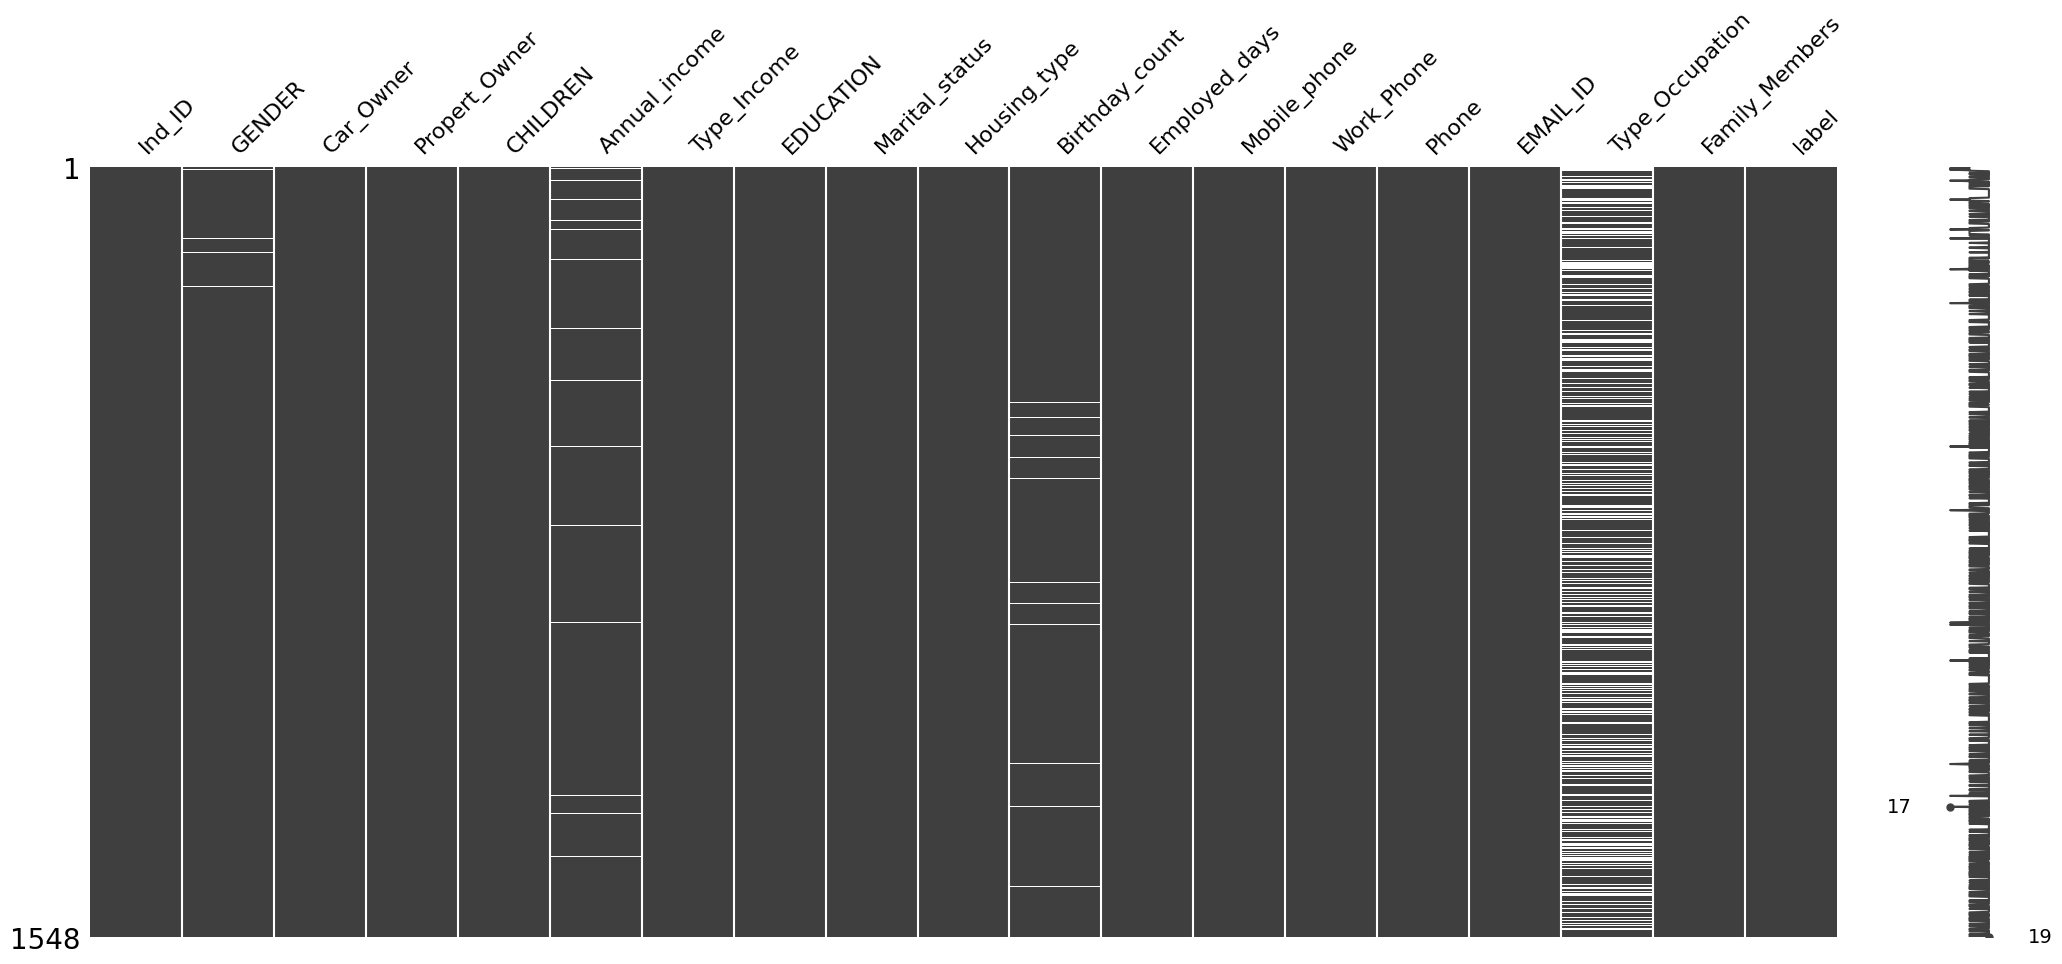

In [13]:
mno.matrix(data)

*Missing value* terlihat terjadi secara random. Kolom dengan jumlah missing value terbanya adalah `Type_Occupation` dimana sekitar 1/3 data pada kolom tersebut hilang.

## Frekuensi tiap kelas label

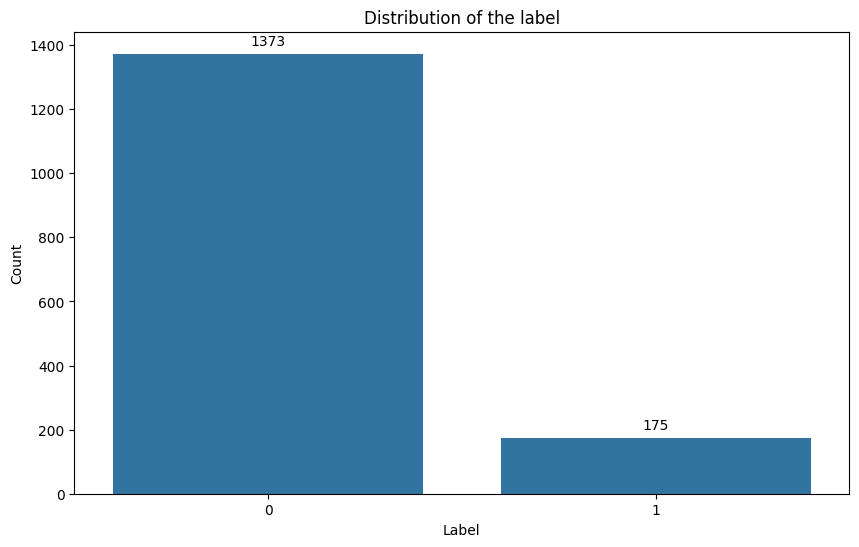

In [14]:

plt.figure(figsize=(10, 6))
ax = sns.countplot(x='label', data=data)
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')
plt.title("Distribution of the label")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

Grafik ini menunjukkan adanya class imbalance pada `label` data nasabah dengan proporsi hampir mencapai 90:10.

## Statistik deskriptif variabel numerik

In [15]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Ind_ID,1548.0,5.078920e+06,41717.587742,5008827.0,5045069.75,5078841.5,5115673.00,5150412.0
CHILDREN,1548.0,4.127907e-01,0.776691,0.0,0.00,0.0,1.00,14.0
Annual_income,1525.0,1.913993e+05,113252.997656,33750.0,121500.00,166500.0,225000.00,1575000.0
Birthday_count,1526.0,-1.604034e+04,4229.503202,-24946.0,-19553.00,-15661.5,-12417.00,-7705.0
Employed_days,1548.0,5.936469e+04,137808.062701,-14887.0,-3174.50,-1565.0,-431.75,365243.0
Mobile_phone,1548.0,1.000000e+00,0.000000,1.0,1.00,1.0,1.00,1.0
Work_Phone,1548.0,2.080103e-01,0.406015,0.0,0.00,0.0,0.00,1.0
Phone,1548.0,3.094315e-01,0.462409,0.0,0.00,0.0,1.00,1.0
EMAIL_ID,1548.0,9.237726e-02,0.289651,0.0,0.00,0.0,0.00,1.0
Family_Members,1548.0,2.161499e+00,0.947772,1.0,2.00,2.0,3.00,15.0


Statistik deskriptif memberikan informasi bahwa nilai `birthday_count` adalah negatif untuk semua baris sedangkan nilai `employed_days` ada yang negatif dan positif.

## Korelasi Variabel Numerik

<Axes: >

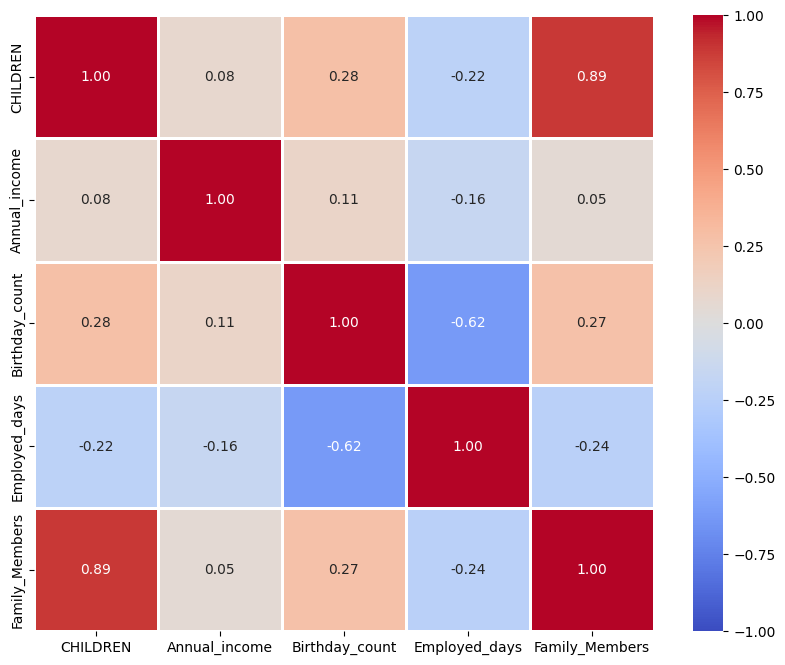

In [16]:
# heatmap
cor1 = data[var_num].corr()
plt.figure(figsize=(10,8))
sns.heatmap(cor1,cmap='coolwarm',annot=True,linecolor='white',linewidths=1, fmt = '.2f',vmin=-1, vmax=1)


## Persebaran data numerik

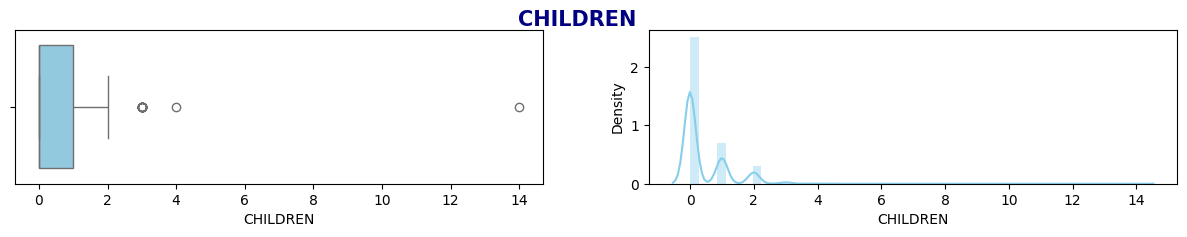

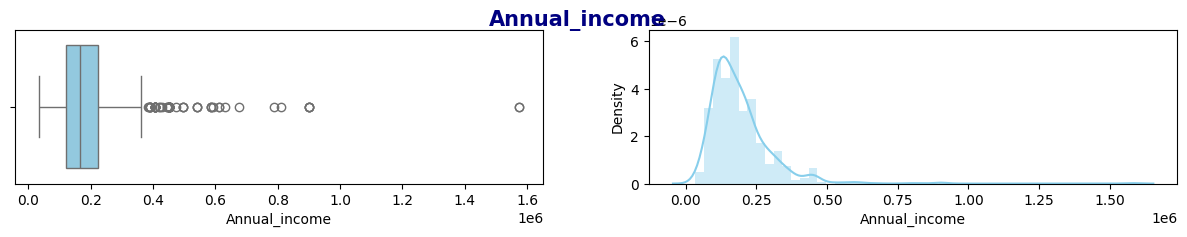

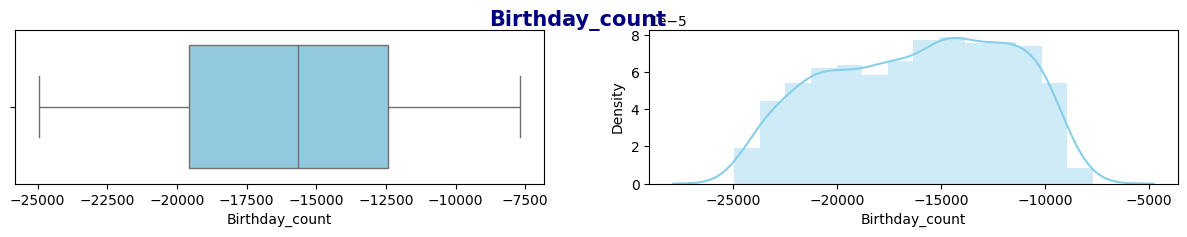

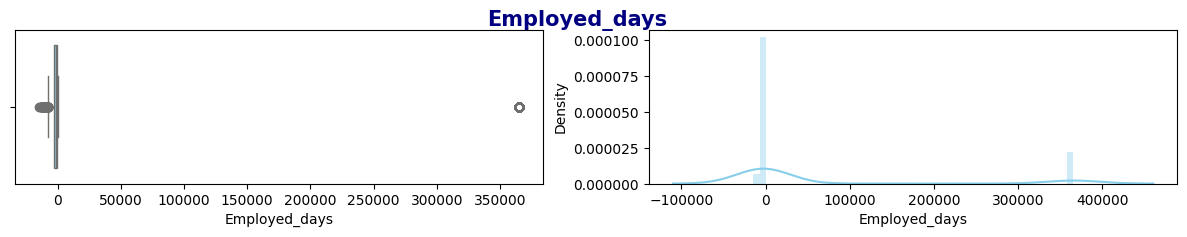

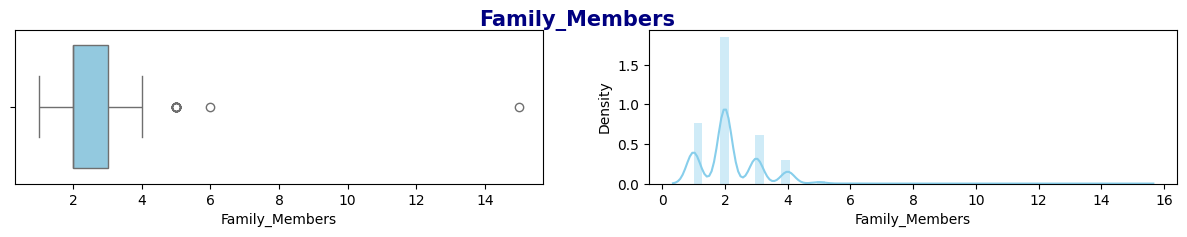

In [17]:
for i in range(0, 5) :
    fig, ax = plt.subplots(1, 2, figsize=(15, 2))
    plt.suptitle(var_num[i], fontsize=15, fontweight='bold', color='navy')
    # Left Plot
    sns.boxplot(x=var_num[i], data=data, ax=ax[0], color = 'skyblue')
    # Right Plot
    sns.distplot(data[var_num[i]], ax=ax[1], color = 'skyblue')

Sebagian besar variabel numerik memiliki pola persebaran yang tidak simetris dan menjurai ke atas.

## Frekuensi tiap kategori pada variabel kategorik

In [18]:
segmen = data[var_cat]
unique_counts = {}
for col in segmen.columns:
    value_counts = segmen[col].value_counts()
    unique_counts[col] = value_counts

for col, counts in unique_counts.items():
    print(f"Column: {counts}")
    print(f"Number of Category: {len(counts)}")
    print()

Column: GENDER
F    973
M    568
Name: count, dtype: int64
Number of Category: 2

Column: Car_Owner
N    924
Y    624
Name: count, dtype: int64
Number of Category: 2

Column: Propert_Owner
Y    1010
N     538
Name: count, dtype: int64
Number of Category: 2

Column: Type_Income
Working                 798
Commercial associate    365
Pensioner               269
State servant           116
Name: count, dtype: int64
Number of Category: 4

Column: EDUCATION
Secondary / secondary special    1031
Higher education                  426
Incomplete higher                  68
Lower secondary                    21
Academic degree                     2
Name: count, dtype: int64
Number of Category: 5

Column: Marital_status
Married                 1049
Single / not married     227
Civil marriage           101
Separated                 96
Widow                     75
Name: count, dtype: int64
Number of Category: 5

Column: Housing_type
House / apartment      1380
With parents             80
Municipal 

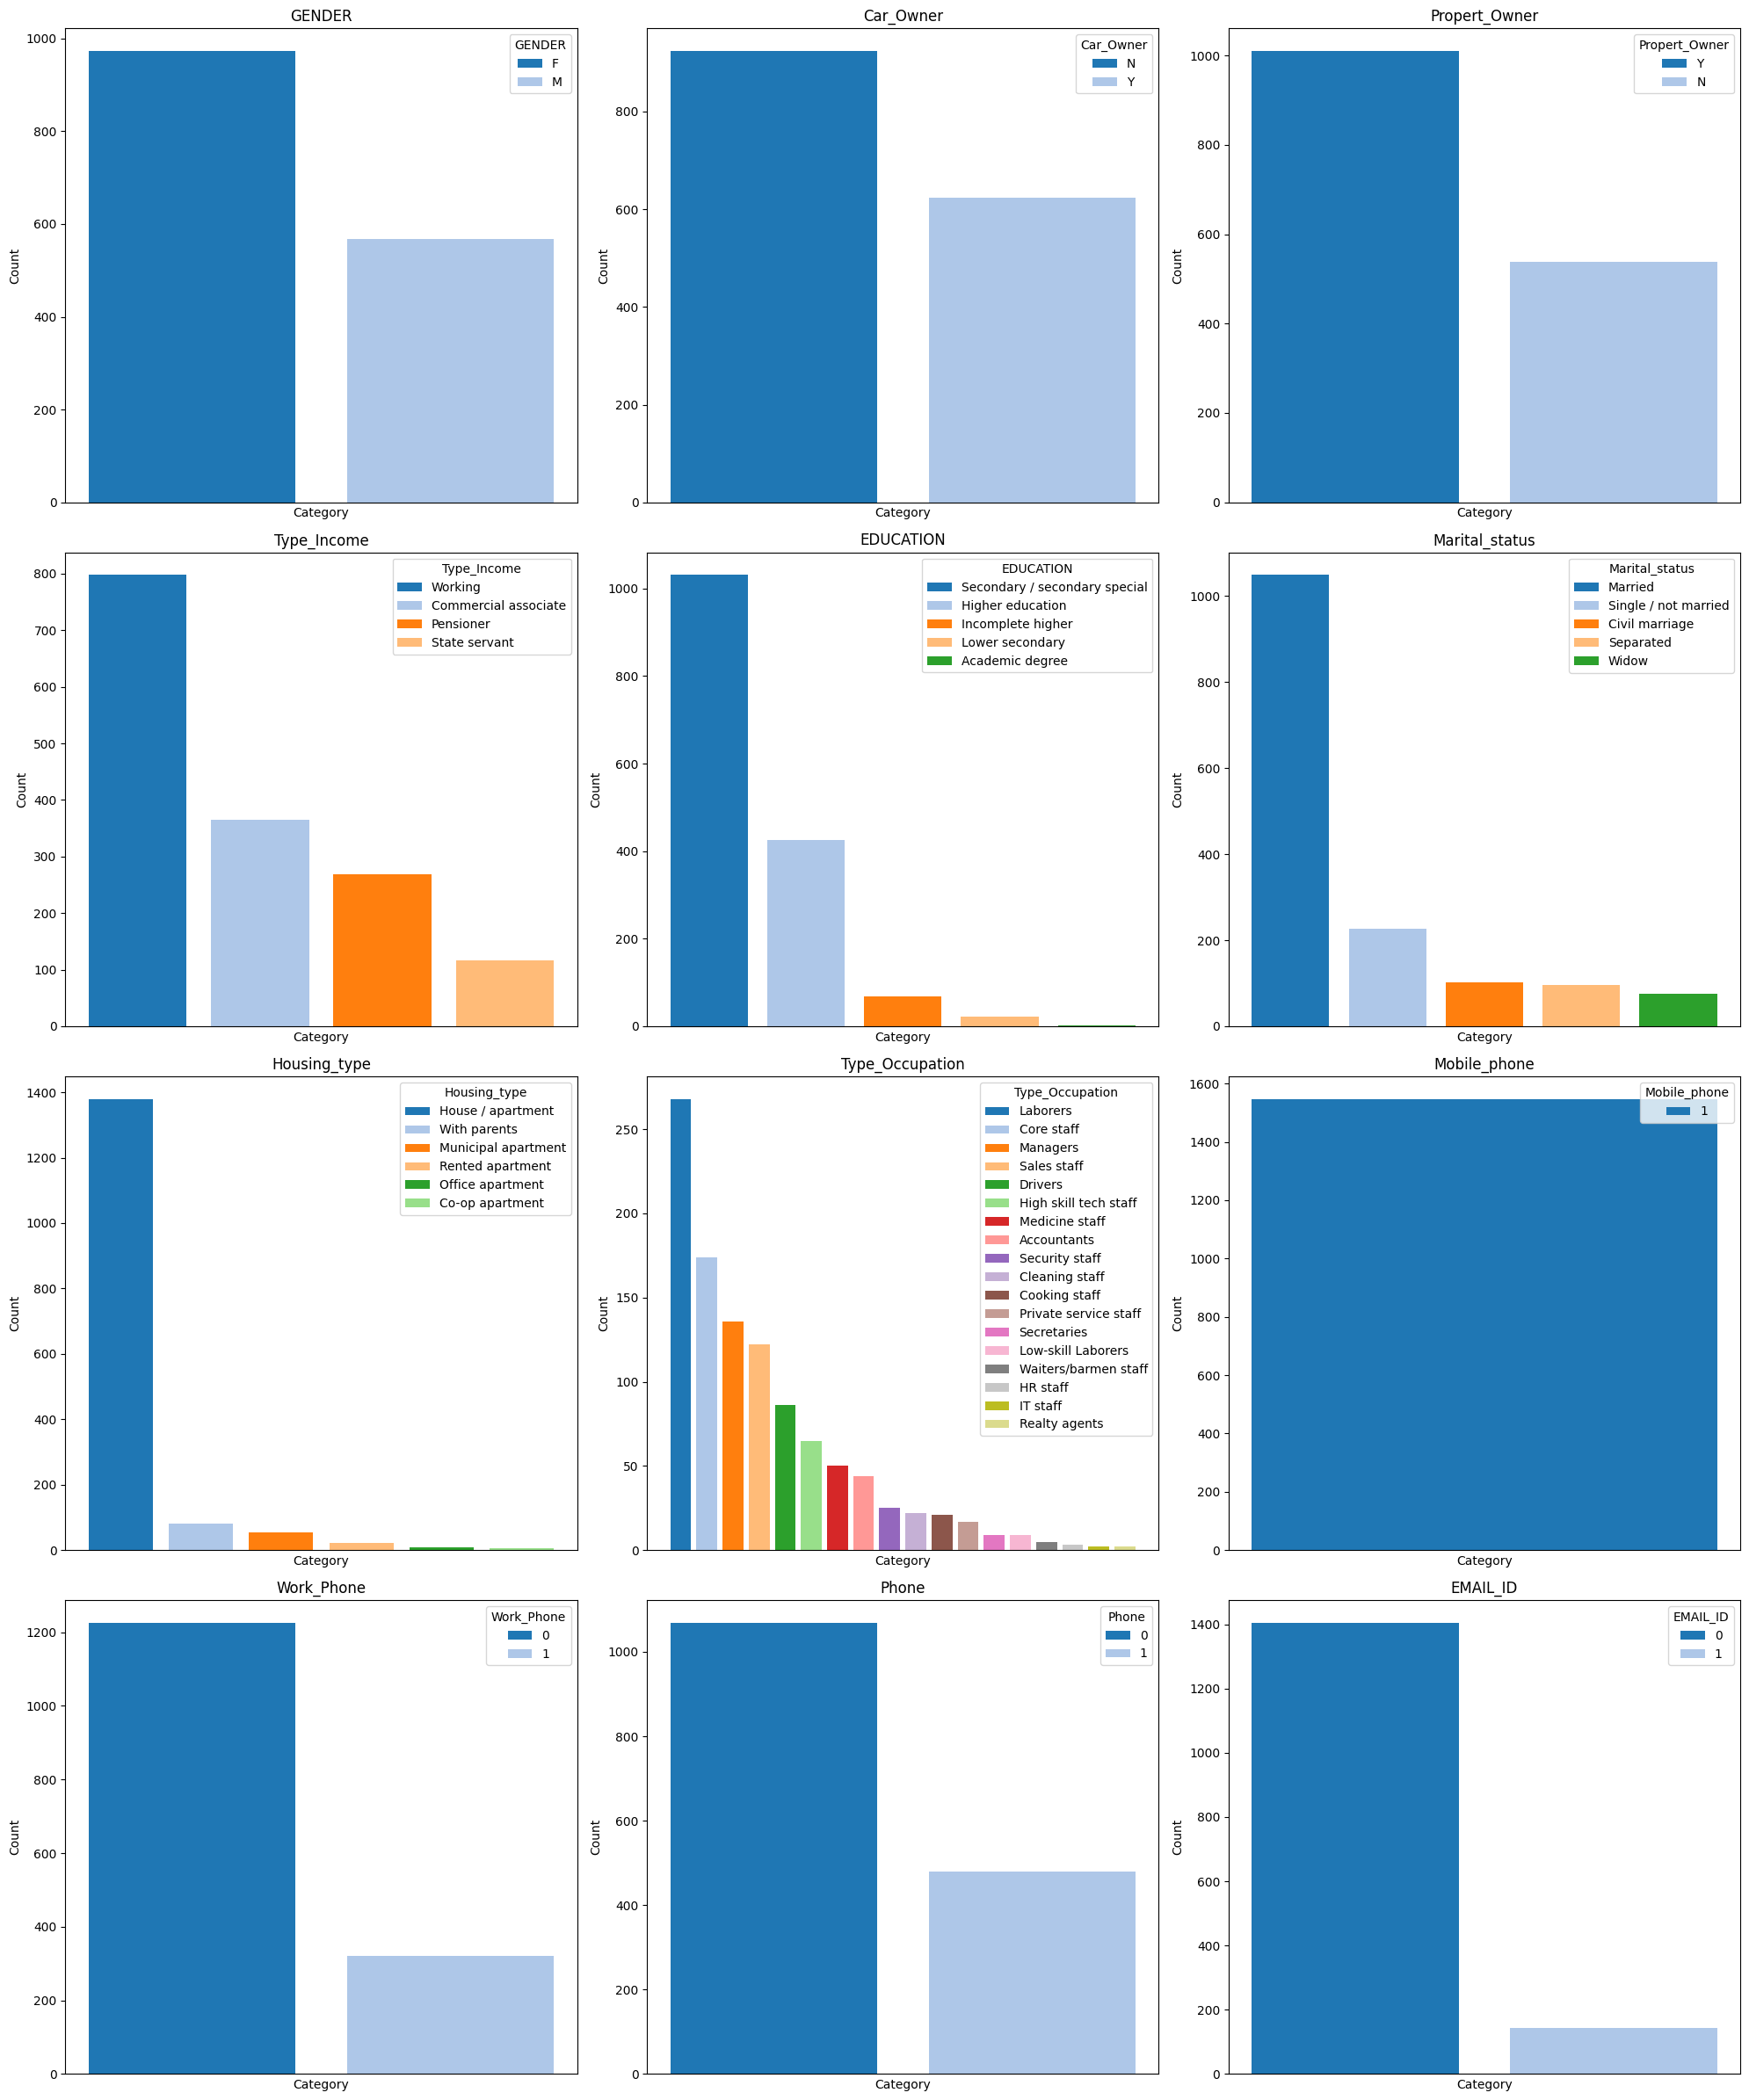

In [19]:
colors = plt.cm.tab20(np.linspace(0, 1, 20))

# Buat subplots sesuai jumlah variabel kategorikal
fig, axes = plt.subplots((len(var_cat) + 2) // 3, 3, figsize=(20, len(var_cat) * 2))
axes = axes.flatten()

# Plot bar chart horizontal untuk setiap variabel kategorik
for i, var in enumerate(var_cat):
    if var in data.columns:
        counts = data[var].value_counts()
        bars = axes[i].bar(counts.index, counts.values, color=colors[:len(counts)], label=counts.index)
        axes[i].set_title(var)
        axes[i].set_ylabel('Count')
        axes[i].set_xlabel('Category')
        axes[i].legend(title=var)
        axes[i].set_xticks([])
    else:
        axes[i].axis('off')

# Adjust layout
plt.tight_layout()
plt.show()

Bagian ini menunjukkan bahwa seluruh baris memiliki nilai yang sama untuk variabel `mobile_phone`. Selain itu, kami juga mengetahui bahwa variabel `type_occupation` memiliki kategori yang banyak.

## Frekuensi tiap kategori pada variabel kategorik yang dikelompokkan bedasarkan label

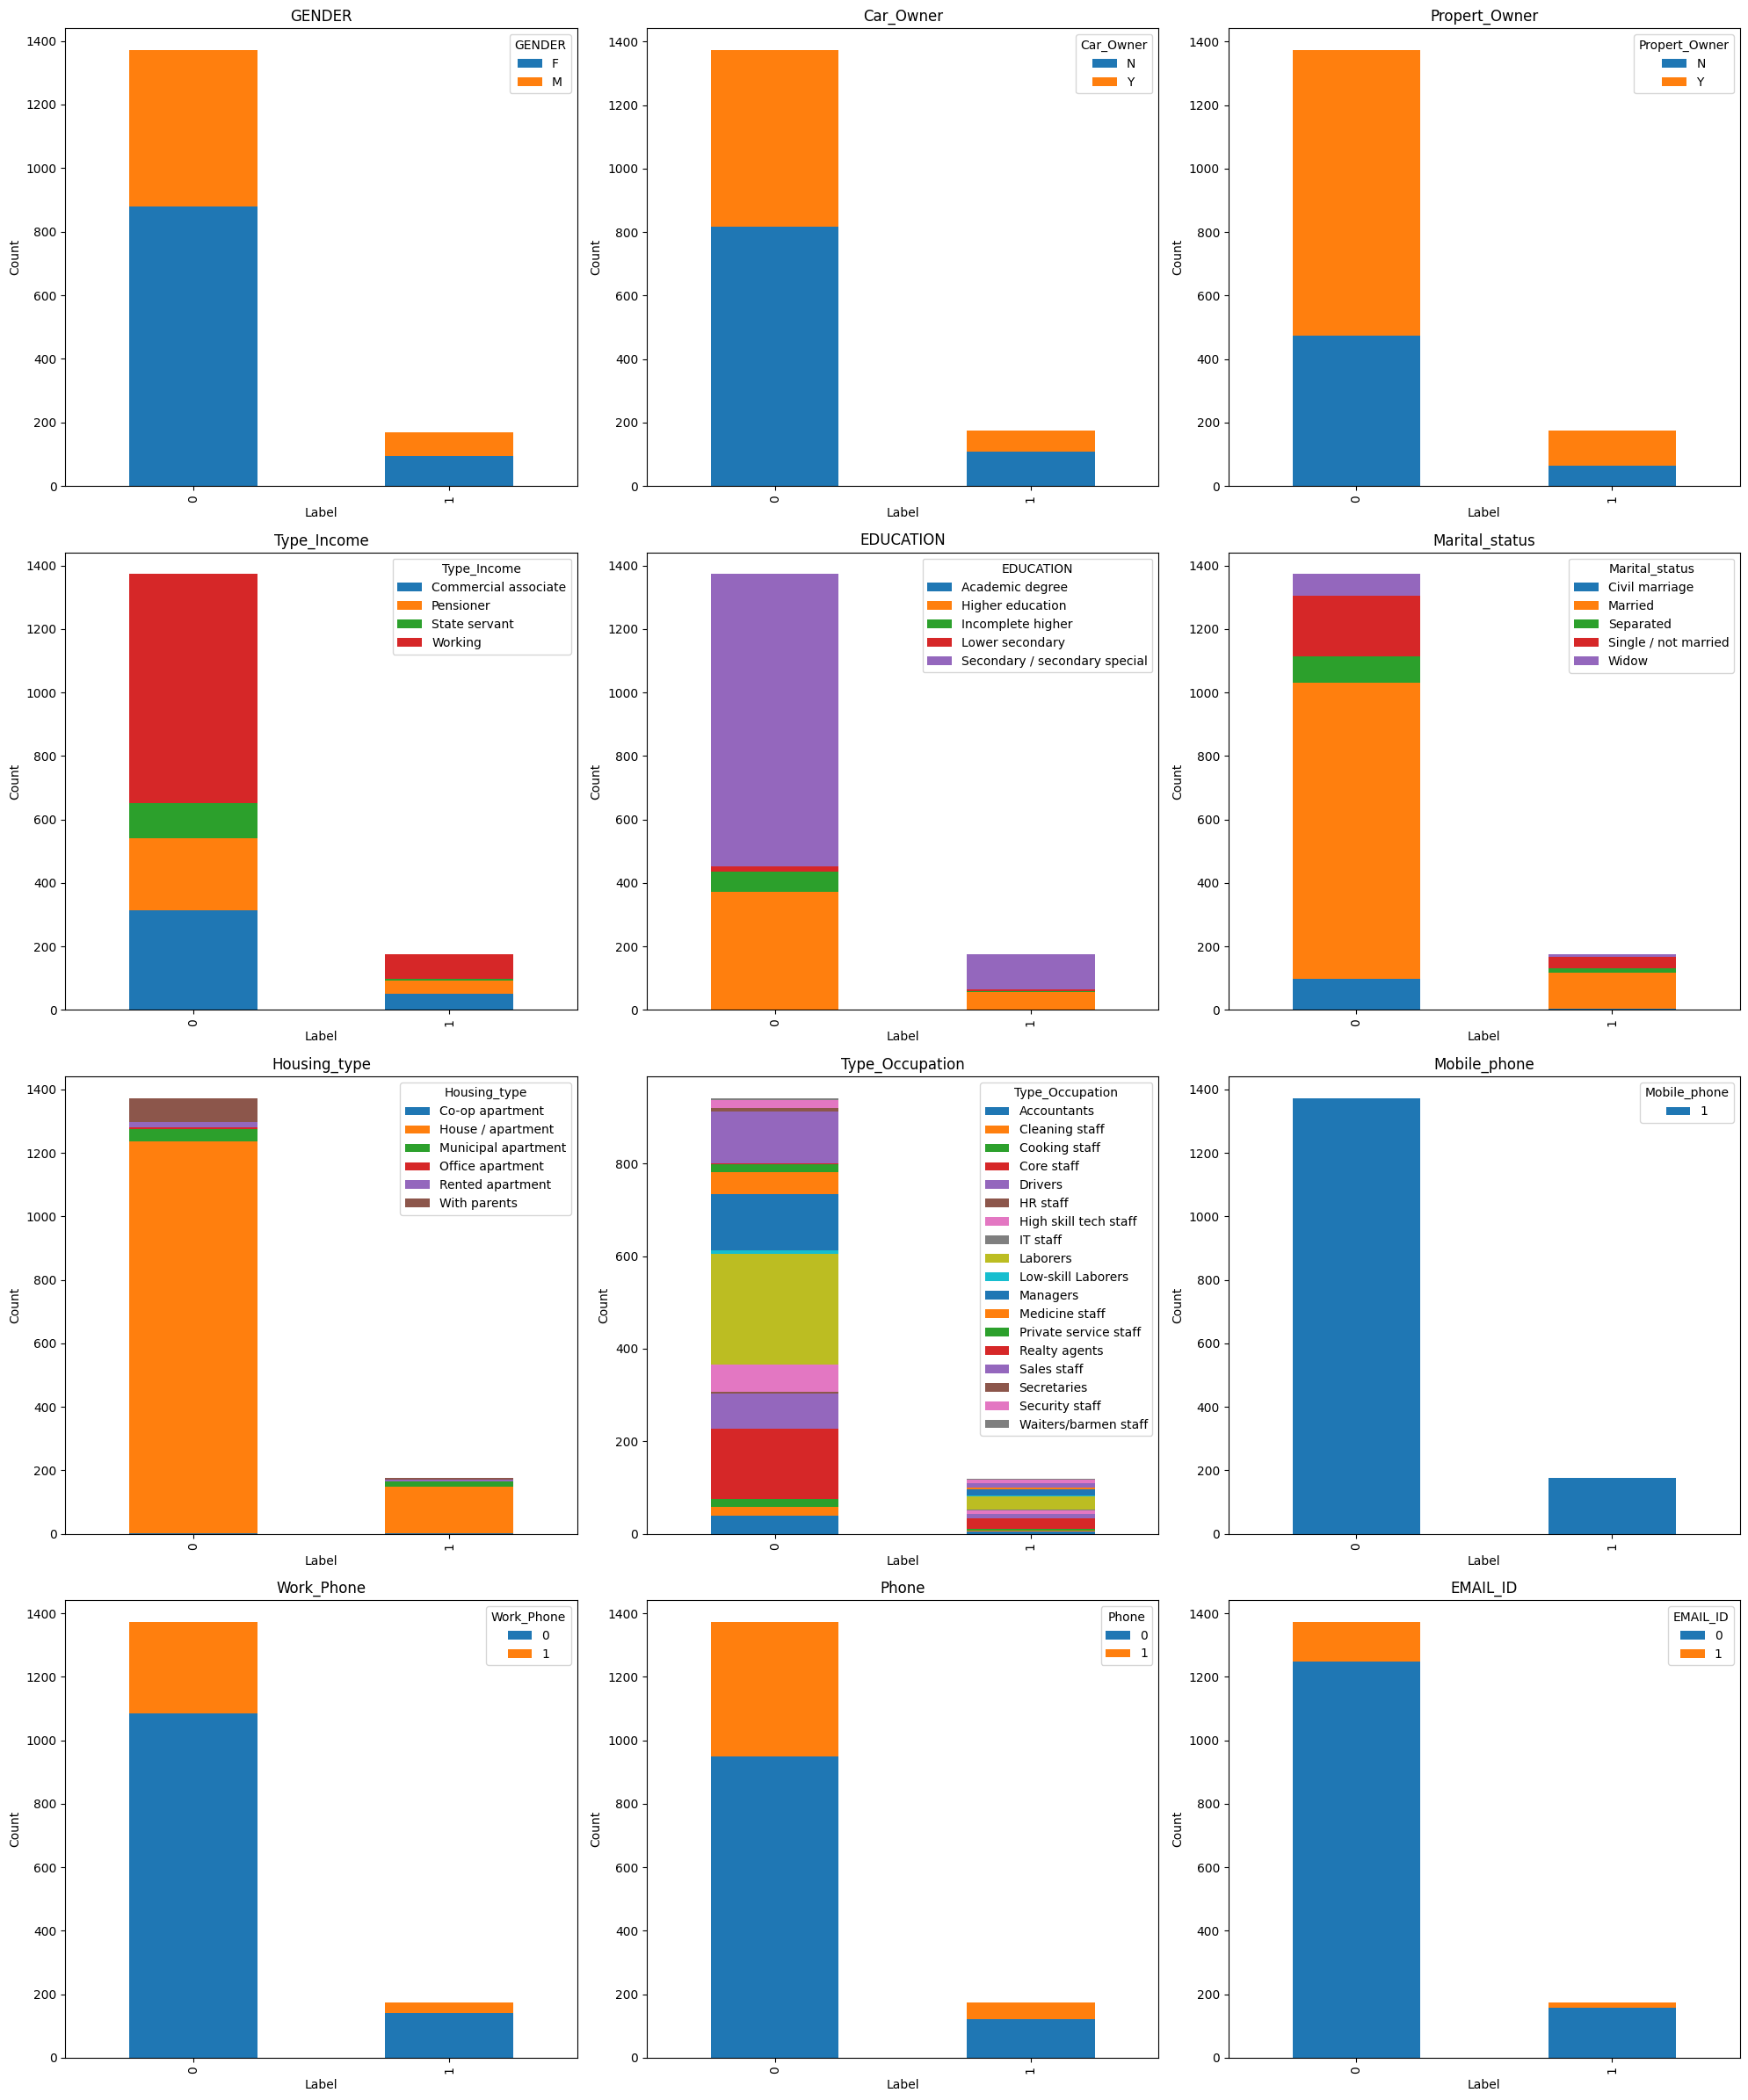

In [20]:
# Buat subplots sesuai jumlah variabel kategorikal
fig, axes = plt.subplots((len(var_cat) + 2) // 3, 3, figsize=(20, len(var_cat) * 2))
axes = axes.flatten()

# Plot stacked bar chart untuk setiap variabel kategorik
for i, var in enumerate(var_cat):
    if var in data.columns:
        counts = data.groupby(['label', var]).size().unstack(fill_value=0)
        counts.plot(kind='bar', stacked=True, ax=axes[i])
        axes[i].set_title(var)
        axes[i].set_ylabel('Count')
        axes[i].set_xlabel('Label')
    else:
        axes[i].axis('off')

# Adjust layout
plt.tight_layout()
plt.show()

# 2 - Feature Engineering

In [21]:
# Mengubah tipe beberapa variabel kategorik menjadi category
data['Work_Phone'] = data['Work_Phone'].astype('category')
data['Phone'] = data['Phone'].astype('category')
data['EMAIL_ID'] = data['EMAIL_ID'].astype('category')
data['label'] = data['label'].astype('category')

Pada bagian berikut, kami membuat 5 variabel baru. Variabel-variabel tersebut diantaranya adalah `Years_Employed`, `Birthday_count`, `Income_per_Family_Number`, `Children_per_Family_Number`, dan `Is_Employed`.

In [22]:
# Pembentukan variabel baru
data['Years_Employed'] = data['Employed_days'] // 365
data['Birthday_count'] = data['Birthday_count'].abs()
data['Income_per_Family_Member'] = data['Annual_income'] / data['Family_Members']
data['Children_per_Family_Member'] = data['CHILDREN'] / data['Family_Members']
data['Is_Employed'] = data['Employed_days'] > 0

In [23]:
data_glm = data.copy()

In [24]:
# Menghapus kolom yang tidak relevan dan tidak dianggap penting
data = data.drop(columns=['Ind_ID', 'Mobile_phone', 'Propert_Owner'])

# 3 - Train Test Splitting

In [25]:
# Memisahkan kolom target dan prediktor
X = data.drop(columns='label')
y = data['label']

# Data splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4 - Preprocessing Pipeline

In [26]:
# Mengambil fitur dengan tipe data tertentu
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Membuat transformer untuk fitur numerik dan kategorik secara terpisah
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Membuat preprocessor berisikan pipeline untuk variabel numerik dan kategorik
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Membuat pipeline akhir
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

In [27]:
# Menerapkan pipeline preprocessing pada data train dan test
X_train_processed = pipeline.fit_transform(X_train)
X_test_processed = pipeline.transform(X_test)



## Re-sampling

### Oversampling

In [ ]:
oversampler = ADASYN(random_state=42)
from imblearn.over_sampling import (
    RandomOverSampler,
    SMOTE,
    SMOTENC,
    SMOTEN,
    ADASYN,
    BorderlineSMOTE,
    KMeansSMOTE,
    SVMSMOTE
)

# Oversampler = RandomOverSampler(random_state=42)
# Oversampler = SMOTE(random_state=42)
# categorical_features = [0, 1]  # Example indices for categorical features
# Oversampler = SMOTENC(categorical_features=categorical_features, random_state=42)
# Oversampler = SMOTEN(random_state=42)
Oversampler = ADASYN(random_state=42)
# Oversampler = BorderlineSMOTE(random_state=42)
# Oversampler = KMeansSMOTE(random_state=42)
# Oversampler = SVMSMOTE(random_state=42)


### Undersampling

In [ ]:
from imblearn.under_sampling import (
    ClusterCentroids,
    CondensedNearestNeighbour,
    EditedNearestNeighbours,
    RepeatedEditedNearestNeighbours,
    AllKNN,
    InstanceHardnessThreshold,
    NearMiss,
    NeighbourhoodCleaningRule,
    OneSidedSelection,
    RandomUnderSampler,
    TomekLinks
)

# Choose your undersampler by uncommenting the one you want to use

# Undersampler = ClusterCentroids(random_state=42)
# Undersampler = CondensedNearestNeighbour(random_state=42)
# Undersampler = EditedNearestNeighbours(random_state=42)
# Undersampler = RepeatedEditedNearestNeighbours(random_state=42)
# Undersampler = AllKNN(random_state=42)
# Undersampler = InstanceHardnessThreshold(random_state=42)
# Undersampler = NearMiss(version=1)  # Specify version 1, 2, or 3
# Undersampler = NeighbourhoodCleaningRule(random_state=42)
# Undersampler = OneSidedSelection(random_state=42)
# Undersampler = RandomUnderSampler(random_state=42)
# Undersampler = TomekLinks()


### Under-Oversampling

In [ ]:
from imblearn.combine import (
    SMOTEENN,
    SMOTETomek
)
# Combined sampler using SMOTEENN
# combined_sampler = SMOTEENN(random_state=42)

# Combined sampler using SMOTETomek
# combined_sampler = SMOTETomek(random_state=42)


In [ ]:
# Melakukan oversampling ADASYN untuk mengatasi class imbalance
X_train_resampled, y_train_resampled = Oversampler.fit_resample(X_train_processed, y_train)

feature_names = numeric_features + pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features).tolist()
X_train_resampled_df = pd.DataFrame(X_train_resampled, columns=feature_names)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=feature_names)

# 5 - Modeling

## Metode Statistik Klasik

Pada tahapan ini, akan dibentuk model klasifikasi menggunakan pendekatan statistik klasik dengan Logistic Regression

In [ ]:
# Memisahkan kolom target dan prediktor
X_glm = data_glm.drop(columns='label')
y_glm = data_glm['label']

# Data splitting
X_train_glm, X_test_glm, y_train_glm, y_test_glm = train_test_split(X_glm, y_glm, test_size=0.2, random_state=42)

In [ ]:
# Mengambil fitur dengan tipe data tertentu
numeric_features = X_glm.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_glm.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

# Membuat transformer untuk fitur numerik dan kategorik secara terpisah
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Membuat preprocessor berisikan pipeline untuk variabel numerik dan kategorik
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Membuat pipeline akhir
pipeline_glm = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

In [ ]:
# Menerapkan pipeline preprocessing pada data train dan test
X_train_processed_glm = pipeline_glm.fit_transform(X_train_glm)
X_test_processed_glm = pipeline_glm.transform(X_test_glm)

# Melakukan oversampling ADASYN untuk mengatasi class imbalance
oversampler = ADASYN(random_state=42)
X_train_resampled_glm, y_train_resampled_glm = oversampler.fit_resample(X_train_processed_glm, y_train_glm)

feature_names = numeric_features + pipeline_glm.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features).tolist()
X_train_resampled_df_glm = pd.DataFrame(X_train_resampled_glm, columns=feature_names)
X_test_processed_df_glm = pd.DataFrame(X_test_processed_glm, columns=feature_names)

In [ ]:
# drop GENDER_F, Car_Owner_N, Propert_Owner_N, Type_Income_Commercial associate,'EDUCATION_Lower secondary','Marital_status_Civil marriage',Housing_type_Co-op apartment,Work_Phone_0,Phone_0,EMAIL_ID_0,Type_Occupation_Accountants,Is_Employed_False
# Drop specified columns from both DataFrames
columns_to_drop = [
    'GENDER_F', 'Car_Owner_N', 'Propert_Owner_N', 'Type_Income_Commercial associate',
    'EDUCATION_Lower secondary', 'Marital_status_Civil marriage', 'Housing_type_Co-op apartment',
    'Type_Occupation_Accountants', 'Is_Employed_False'
]

X_train_resampled_df_glm.drop(columns=columns_to_drop, inplace=True)
X_test_processed_df_glm.drop(columns=columns_to_drop, inplace=True)

X_train_resampled_df_glm.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2189 entries, 0 to 2188
Data columns (total 53 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Ind_ID                                   2189 non-null   float64
 1   CHILDREN                                 2189 non-null   float64
 2   Annual_income                            2189 non-null   float64
 3   Birthday_count                           2189 non-null   float64
 4   Employed_days                            2189 non-null   float64
 5   Mobile_phone                             2189 non-null   float64
 6   Family_Members                           2189 non-null   float64
 7   Years_Employed                           2189 non-null   float64
 8   Income_per_Family_Member                 2189 non-null   float64
 9   Children_per_Family_Member               2189 non-null   float64
 10  GENDER_M                                 2189 no

on

### Check High correlat

In [ ]:
# Check for high correlation among features
corr_matrix = X_train_resampled_df_glm.corr().abs()
high_corr_var = np.where(corr_matrix > 0.8)
high_corr_var = [(corr_matrix.columns[x], corr_matrix.columns[y]) for x, y in zip(*high_corr_var) if x != y and x < y]

# Print highly correlated features
print(f"Highly correlated features: {high_corr_var}")


Highly correlated features: [('CHILDREN', 'Family_Members'), ('CHILDREN', 'Children_per_Family_Member'), ('Employed_days', 'Years_Employed'), ('Employed_days', 'Type_Income_Pensioner'), ('Employed_days', 'Is_Employed_True'), ('Years_Employed', 'Type_Income_Pensioner'), ('Years_Employed', 'Is_Employed_True'), ('Type_Income_Pensioner', 'Is_Employed_True'), ('EDUCATION_Higher education', 'EDUCATION_Secondary / secondary special'), ('Work_Phone_0', 'Work_Phone_1'), ('Phone_0', 'Phone_1'), ('EMAIL_ID_0', 'EMAIL_ID_1')]


## Logistic Regression : Biner

In [ ]:
import statsmodels.api as sm

# Adding a constant to the features for an intercept
X_train_resampled_glm_const = sm.add_constant(X_train_resampled_df_glm)
X_test_processed_glm_const = sm.add_constant(X_test_processed_df_glm)

# Fitting logistic regression model using statsmodels
logit_model = sm.Logit(y_train_resampled_glm, X_train_resampled_glm_const)
result = logit_model.fit()

# Displaying the summary of the logistic regression model
print(result.summary())


         Current function value: 0.581228
         Iterations: 35


LinAlgError: Singular matrix

In [ ]:
from sklearn.decomposition import PCA
import numpy as np

# Step 1: Check for high correlations
corr_matrix = X_train_resampled_df_glm.corr().abs()
high_corr_var = np.where(corr_matrix > 0.8)
high_corr_var = [(corr_matrix.columns[x], corr_matrix.columns[y]) for x, y in zip(*high_corr_var) if x != y and x < y]
print(f"Highly correlated features: {high_corr_var}")

# Step 2: Apply PCA to reduce dimensionality
pca = PCA(n_components=0.95, random_state=42)  # Retain 95% of the variance
X_train_pca = pca.fit_transform(X_train_resampled_df_glm)
X_test_pca = pca.transform(X_test_processed_df_glm)

# Step 3: Re-Fit Logistic Regression
X_train_pca_const = sm.add_constant(X_train_pca)
logit_model_pca = sm.Logit(y_train_resampled_glm, X_train_pca_const)
result_pca = logit_model_pca.fit()

# Displaying the summary of the logistic regression model after PCA
print(result_pca.summary())


Highly correlated features: [('CHILDREN', 'Family_Members'), ('CHILDREN', 'Children_per_Family_Member'), ('Employed_days', 'Years_Employed'), ('Employed_days', 'Type_Income_Pensioner'), ('Employed_days', 'Is_Employed_True'), ('Years_Employed', 'Type_Income_Pensioner'), ('Years_Employed', 'Is_Employed_True'), ('Type_Income_Pensioner', 'Is_Employed_True'), ('EDUCATION_Higher education', 'EDUCATION_Secondary / secondary special'), ('Work_Phone_0', 'Work_Phone_1'), ('Phone_0', 'Phone_1'), ('EMAIL_ID_0', 'EMAIL_ID_1')]
Optimization terminated successfully.
         Current function value: 0.671031
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                  label   No. Observations:                 2189
Model:                          Logit   Df Residuals:                     2170
Method:                           MLE   Df Model:                           18
Date:                Fri, 04 Oct 2024   Pseudo R-squ.:        

In [ ]:
# Add a constant to the test PCA data for the intercept
X_test_pca_const = sm.add_constant(X_test_pca)

# Generate predicted probabilities on the test set
y_test_pred_probs = result_pca.predict(X_test_pca_const)

# Convert probabilities to binary predictions (using 0.5 as threshold)
y_test_pred = (y_test_pred_probs >= 0.5).astype(int)

# Display the predictions
print("Predicted probabilities:", y_test_pred_probs[:10])  # Display first 10 probabilities for reference
print("Binary predictions:", y_test_pred[:10])  # Display first 10 binary predictions for reference


Predicted probabilities: [0.48823884 0.60382002 0.43472648 0.53263644 0.48830933 0.65733601
 0.43353607 0.58373761 0.39897747 0.56267803]
Binary predictions: [0 1 0 1 0 1 0 1 0 1]


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate the confusion matrix
conf_matrix = confusion_matrix(y_test_glm, y_test_pred)
print("Confusion Matrix:\n", conf_matrix)

# Generate the classification report
class_report = classification_report(y_test_glm, y_test_pred)
print("\nClassification Report:\n", class_report)


Confusion Matrix:
 [[160 120]
 [ 16  14]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.57      0.70       280
           1       0.10      0.47      0.17        30

    accuracy                           0.56       310
   macro avg       0.51      0.52      0.44       310
weighted avg       0.83      0.56      0.65       310



### Diagnostic checking : Hosmer Lemeshow Test

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 310 entries, 30 to 874
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   y_true       310 non-null    category
 1   y_pred_prob  310 non-null    float64 
 2   group        310 non-null    int64   
dtypes: category(1), float64(1), int64(1)
memory usage: 7.7 KB


In [ ]:
import numpy as np
from scipy.stats import chi2

# Convert 'y_true' to integer type to allow mathematical operations
data['y_true'] = data['y_true'].astype(int)

# Observed vs. Expected counts for each group
observed = data.groupby('group')['y_true'].sum()          # Observed event count in each group
expected = data.groupby('group')['y_pred_prob'].sum()     # Expected event count in each group
total = data.groupby('group')['y_true'].count()           # Total count in each group

# Calculate the Hosmer-Lemeshow statistic
hl_stat = np.sum((observed - expected) ** 2 / (expected * (1 - expected / total)))
p_value = 1 - chi2.cdf(hl_stat, df=n_groups - 2)  # Degrees of freedom = n_groups - 2

print("Hosmer-Lemeshow Test Statistic:", hl_stat)
print("p-value:", p_value)


Hosmer-Lemeshow Test Statistic: 212.5622022029502
p-value: 0.0


At α = 0.05 we  reject the hypothesis that the data fit the
model (p = 0.0). Therefore we conclude that the model
provides is not fit.

### ROC AUC

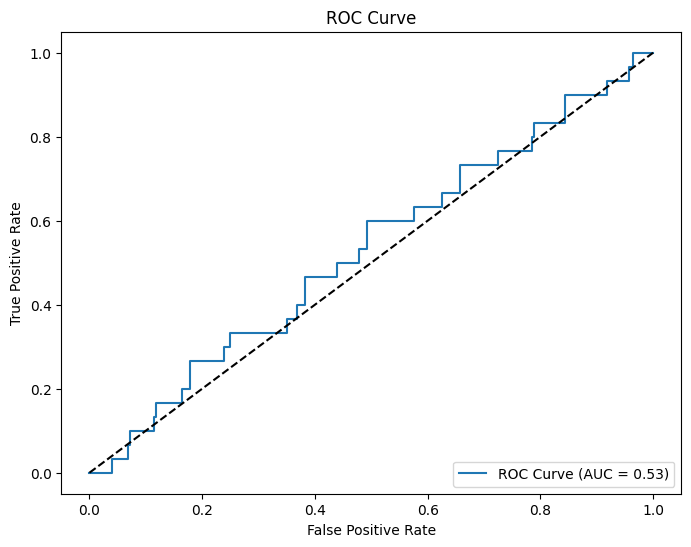

AUC Score: 0.5284523809523809


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test_glm, y_test_pred_probs)
auc_score = roc_auc_score(y_test_glm, y_test_pred_probs)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # 45-degree line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

print("AUC Score:", auc_score)


A higher AUC (closer to 1) indicates better model performance.

### Brier Score

In [ ]:
from sklearn.metrics import brier_score_loss

# Calculate Brier Score
brier_score = brier_score_loss(y_test_glm, y_test_pred_probs)
print("Brier Score:", brier_score)


Brier Score: 0.2508427074087116


A lower Brier score (closer to 0) suggests better probability predictions.

## Multinomial LR

In [ ]:
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import MNLogit

# Assuming y_train_resampled_glm is your categorical target variable
# Ensure that y_train_resampled_glm is of type categorical
y_train_resampled_glm = y_train_resampled_glm.astype('category')

# Adding a constant to the features for an intercept
X_train_resampled_glm_const = sm.add_constant(X_train_resampled_df_glm)
X_test_processed_glm_const = sm.add_constant(X_test_processed_df_glm)

# Fitting multinomial logistic regression model using statsmodels
mnlogit_model = MNLogit(y_train_resampled_glm, X_train_resampled_glm_const)
mnlogit_result = mnlogit_model.fit()

# Displaying the summary of the multinomial logistic regression model
print(mnlogit_result.summary())

## Metode Machine Learning Sederhana

Note!!!!!!!!! Run ulang data dan prepro agar bisa jalan

Akan dilakukan modeling dengan menerapkan suatu metode threshold moving demi menjaga model tetap robust terhadap adanya class imbalance. Metode treshold moving yang dilakukan adalah menentukan classification threshold menggunakan geometric mean.

In [ ]:
# Menerapkan pipeline preprocessing pada data train dan test
X_train_processed = pipeline.fit_transform(X_train)
X_test_processed = pipeline.transform(X_test)

# Melakukan oversampling ADASYN untuk mengatasi class imbalance
oversampler = ADASYN(random_state=42)
X_train_resampled, y_train_resampled = oversampler.fit_resample(X_train_processed, y_train)

feature_names = numeric_features + pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features).tolist()
X_train_resampled_df = pd.DataFrame(X_train_resampled, columns=feature_names)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=feature_names)

### ML Baseline model

Classification Report for KNeighborsClassifier:
              precision    recall  f1-score   support

           0      0.943     0.711     0.811       280
           1      0.182     0.600     0.279        30

    accuracy                          0.700       310
   macro avg      0.562     0.655     0.545       310
weighted avg      0.869     0.700     0.759       310



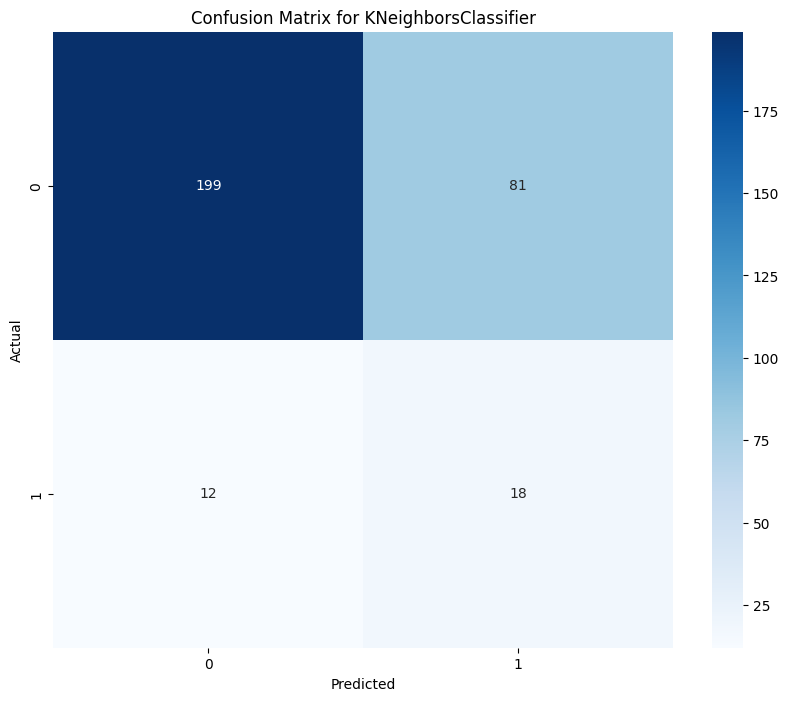

Classification Report for RandomForestClassifier:
              precision    recall  f1-score   support

           0      0.936     0.993     0.964       280
           1      0.846     0.367     0.512        30

    accuracy                          0.932       310
   macro avg      0.891     0.680     0.738       310
weighted avg      0.927     0.932     0.920       310



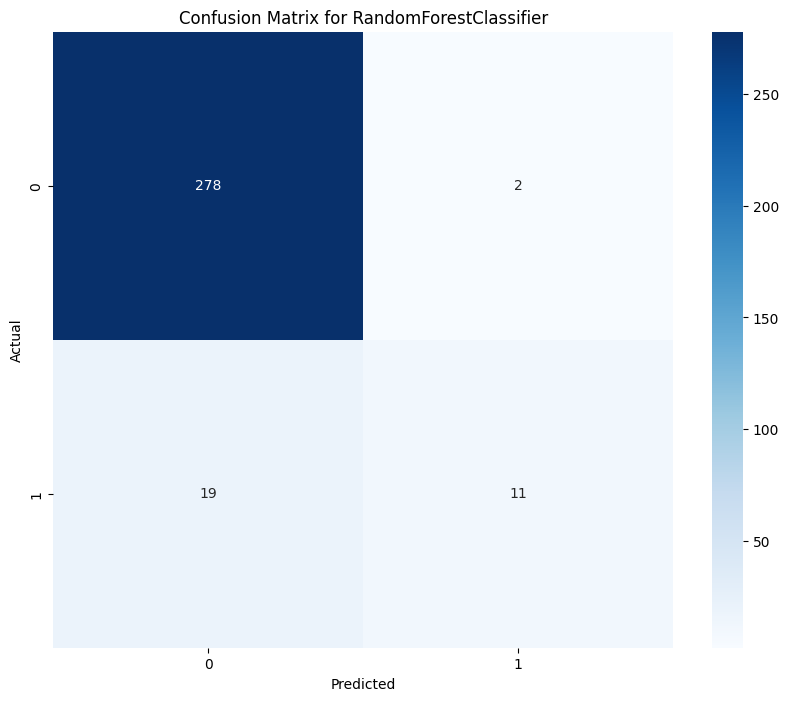

Classification Report for XGBClassifier:
              precision    recall  f1-score   support

           0      0.942     0.982     0.962       280
           1      0.722     0.433     0.542        30

    accuracy                          0.929       310
   macro avg      0.832     0.708     0.752       310
weighted avg      0.921     0.929     0.921       310



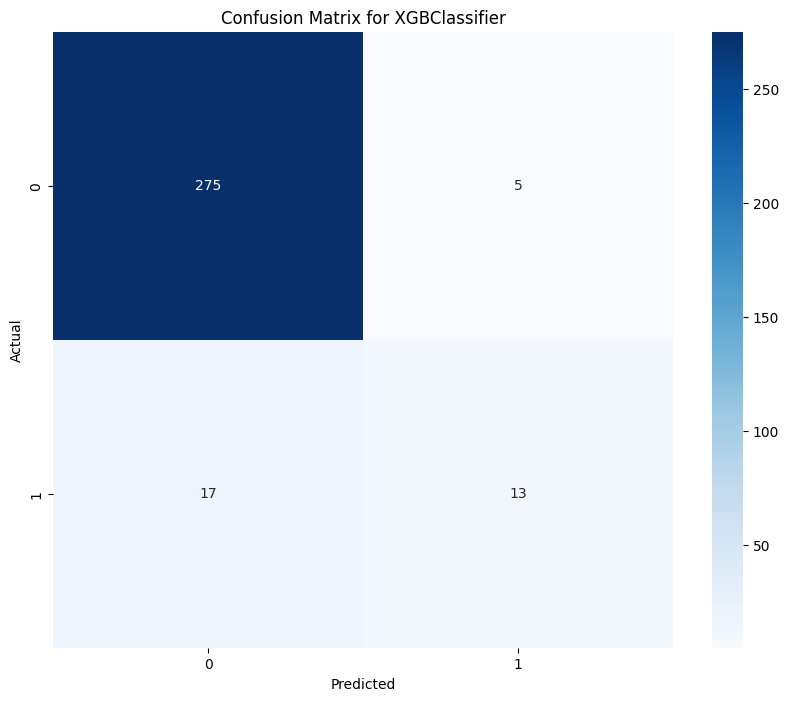

[LightGBM] [Info] Number of positive: 1086, number of negative: 1093
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001110 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2703
[LightGBM] [Info] Number of data points in the train set: 2179, number of used features: 47
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.498394 -> initscore=-0.006425
[LightGBM] [Info] Start training from score -0.006425
Classification Report for LGBMClassifier:
              precision    recall  f1-score   support

           0      0.936     0.986     0.960       280
           1      0.733     0.367     0.489        30

    accuracy                          0.926       310
   macro avg      0.834     0.676     0.724       310
weighted avg      0.916     0.926     0.914       310



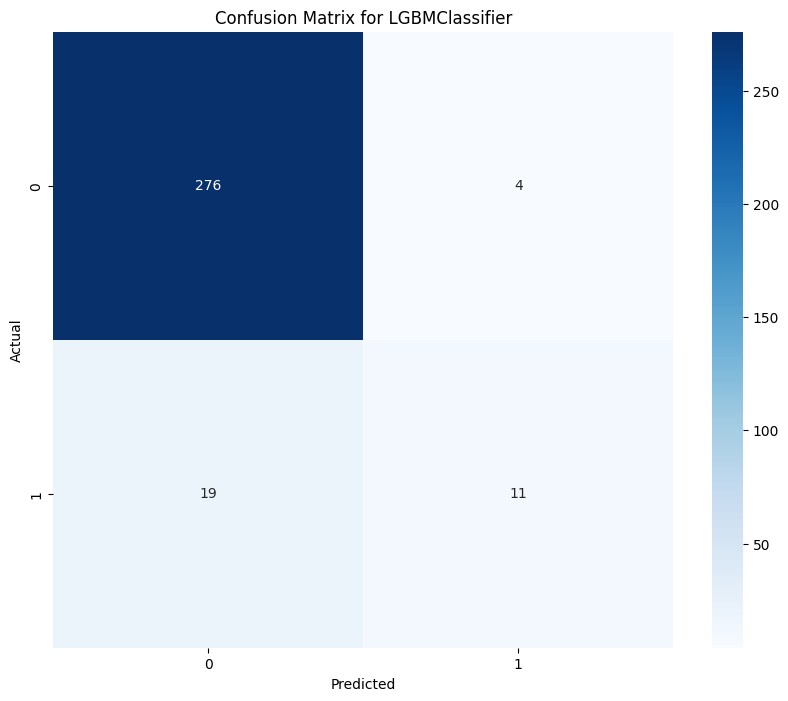

Classification Report for LogisticRegression:
              precision    recall  f1-score   support

           0      0.925     0.661     0.771       280
           1      0.136     0.500     0.214        30

    accuracy                          0.645       310
   macro avg      0.531     0.580     0.493       310
weighted avg      0.849     0.645     0.717       310



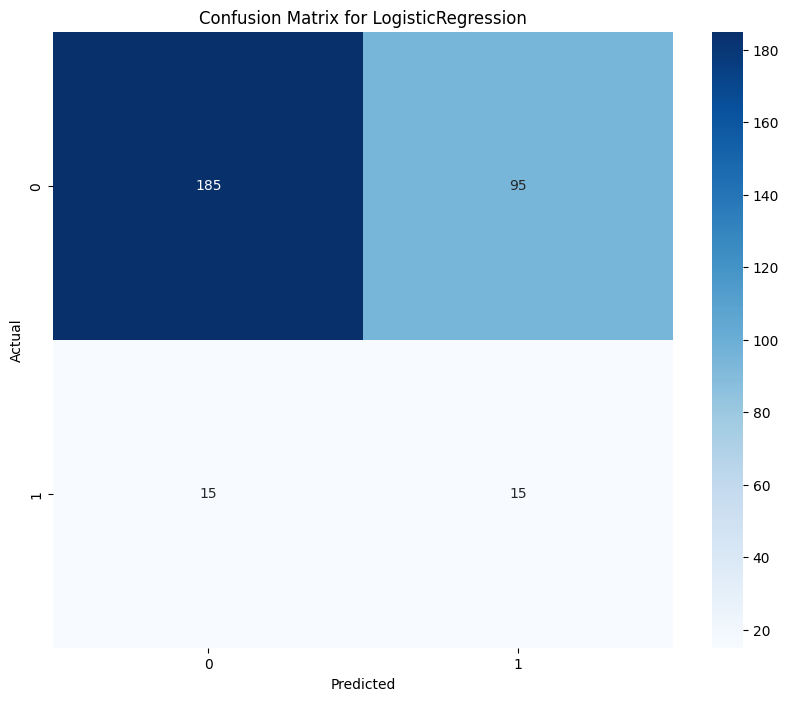

Classification Report for SVC:
              precision    recall  f1-score   support

           0      0.937     0.854     0.893       280
           1      0.255     0.467     0.329        30

    accuracy                          0.816       310
   macro avg      0.596     0.660     0.611       310
weighted avg      0.871     0.816     0.839       310



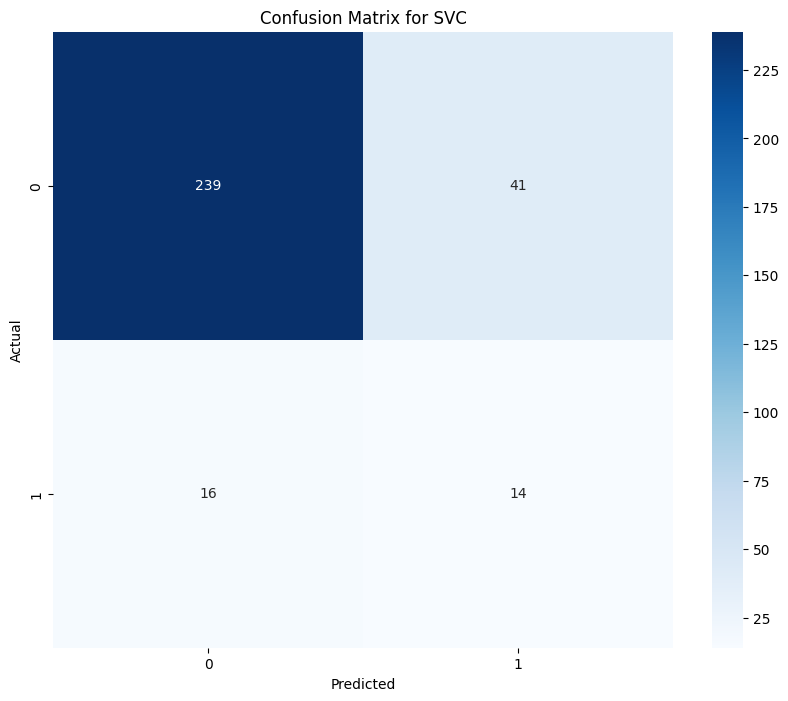

Classification Report for DecisionTreeClassifier:
              precision    recall  f1-score   support

           0      0.940     0.900     0.920       280
           1      0.333     0.467     0.389        30

    accuracy                          0.858       310
   macro avg      0.637     0.683     0.654       310
weighted avg      0.882     0.858     0.868       310



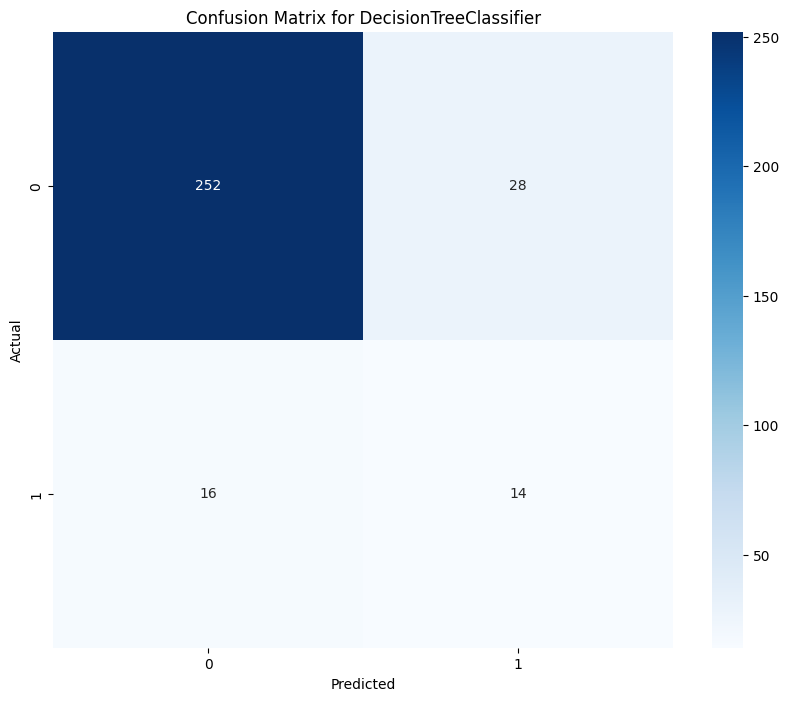

Classification Report for GradientBoostingClassifier:
              precision    recall  f1-score   support

           0      0.918     0.964     0.941       280
           1      0.375     0.200     0.261        30

    accuracy                          0.890       310
   macro avg      0.647     0.582     0.601       310
weighted avg      0.866     0.890     0.875       310



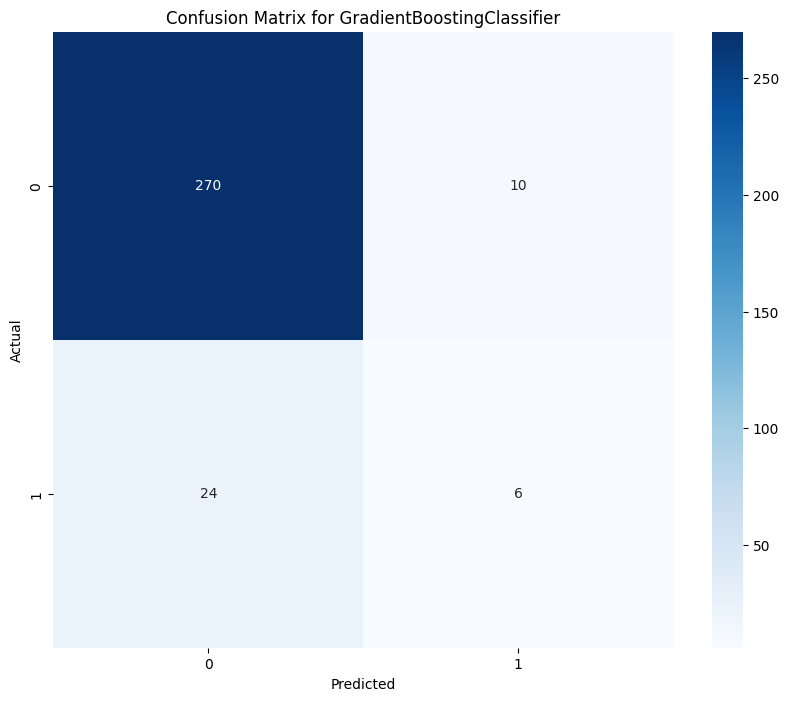

Classification Report for AdaBoostClassifier:
              precision    recall  f1-score   support

           0      0.923     0.893     0.907       280
           1      0.231     0.300     0.261        30

    accuracy                          0.835       310
   macro avg      0.577     0.596     0.584       310
weighted avg      0.856     0.835     0.845       310



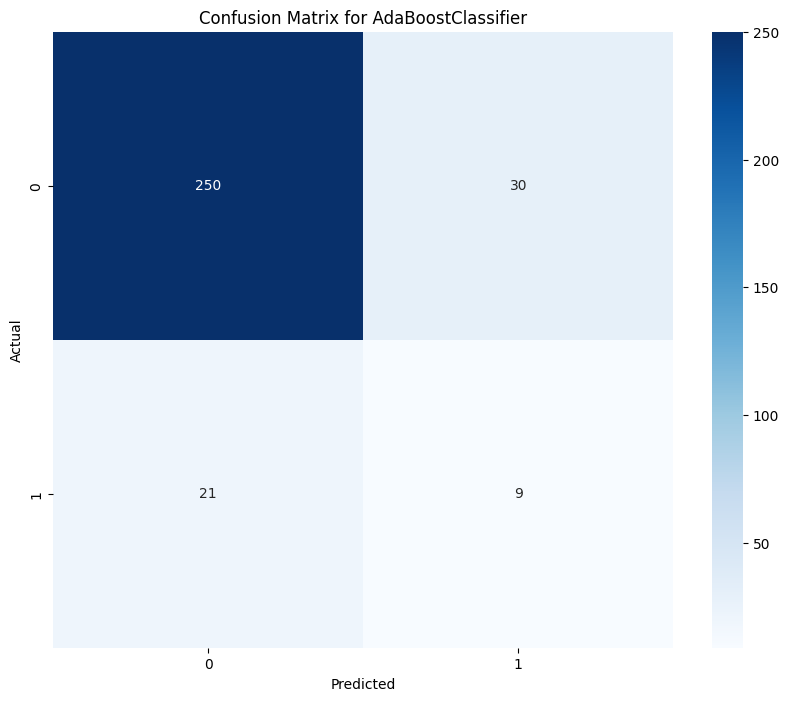

Classification Report for BaggingClassifier:
              precision    recall  f1-score   support

           0      0.947     0.950     0.948       280
           1      0.517     0.500     0.508        30

    accuracy                          0.906       310
   macro avg      0.732     0.725     0.728       310
weighted avg      0.905     0.906     0.906       310



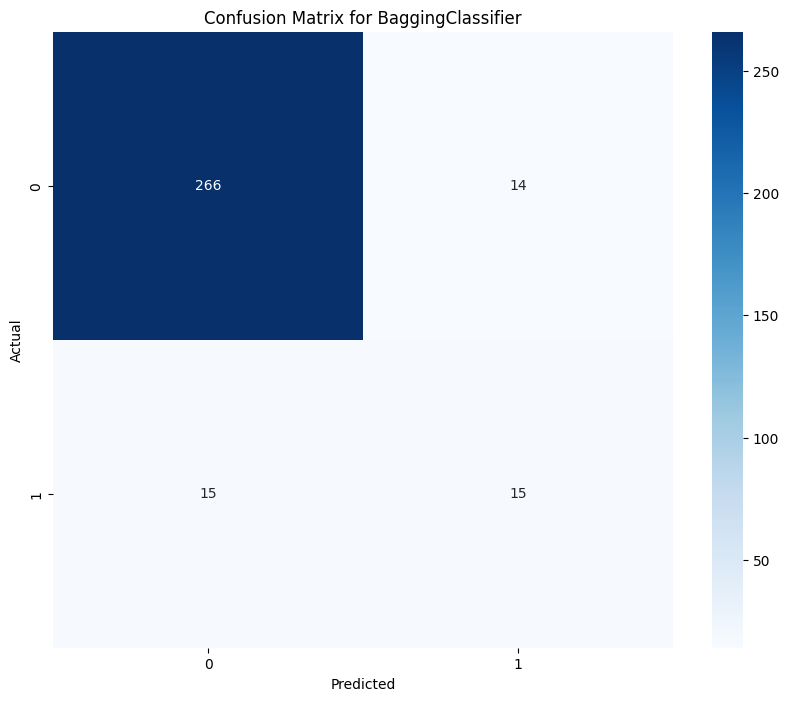

Classification Report for ExtraTreesClassifier:
              precision    recall  f1-score   support

           0      0.941     0.975     0.958       280
           1      0.650     0.433     0.520        30

    accuracy                          0.923       310
   macro avg      0.796     0.704     0.739       310
weighted avg      0.913     0.923     0.916       310



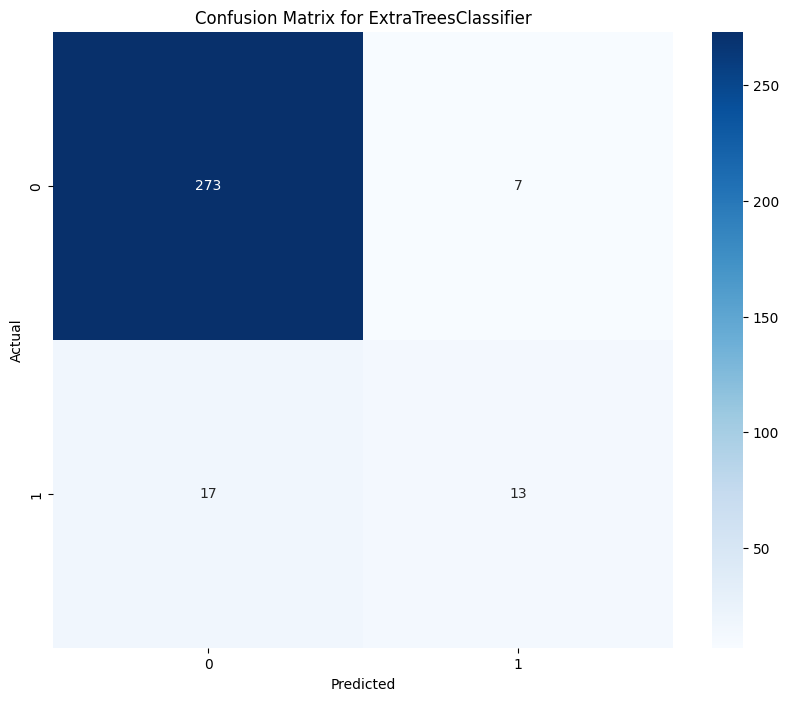

Classification Report for CatBoostClassifier:
              precision    recall  f1-score   support

           0      0.929     0.979     0.953       280
           1      0.600     0.300     0.400        30

    accuracy                          0.913       310
   macro avg      0.764     0.639     0.677       310
weighted avg      0.897     0.913     0.900       310



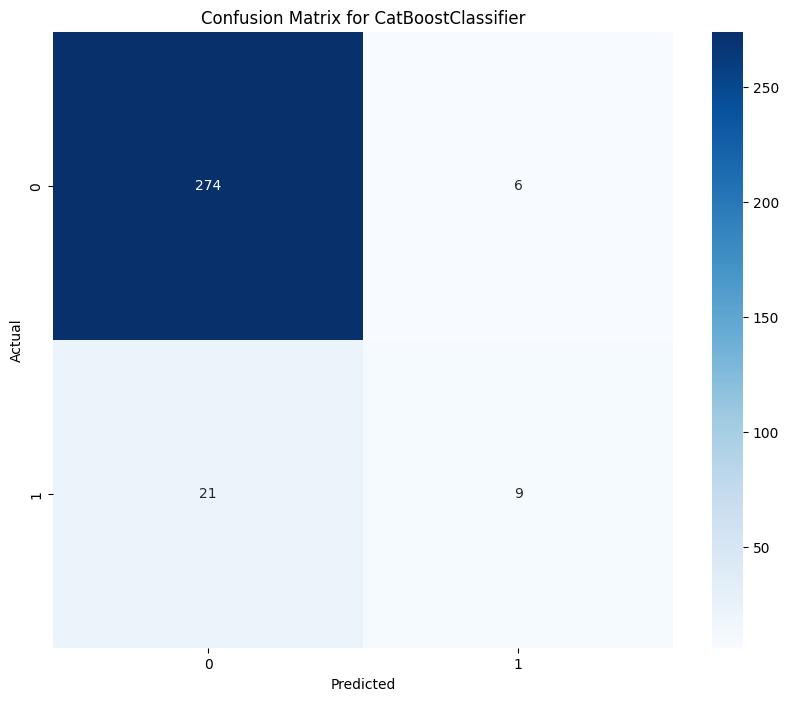

Classification Report for GaussianNB:
              precision    recall  f1-score   support

           0      0.931     0.096     0.175       280
           1      0.100     0.933     0.180        30

    accuracy                          0.177       310
   macro avg      0.515     0.515     0.177       310
weighted avg      0.851     0.177     0.175       310



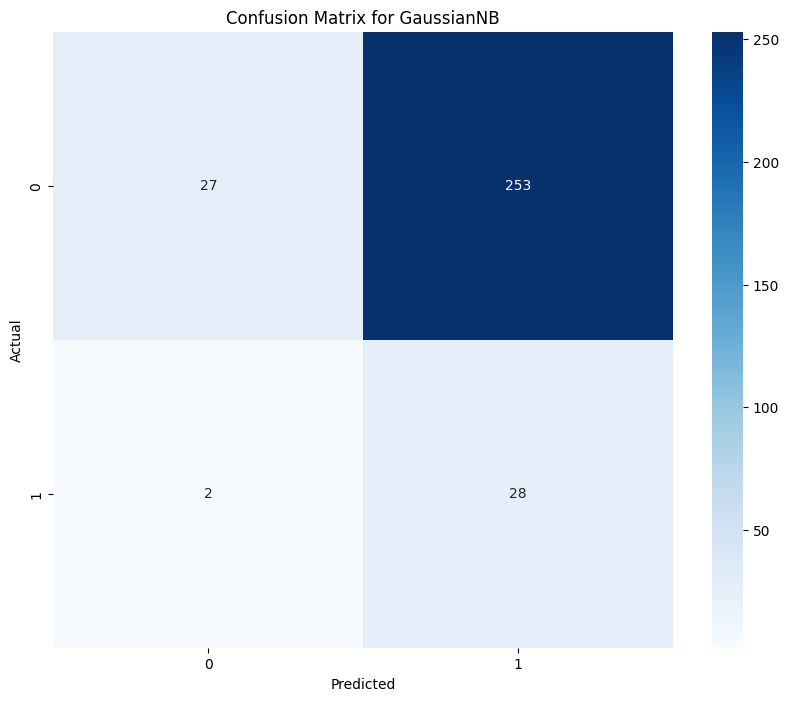

Classification Report for MLPClassifier:
              precision    recall  f1-score   support

           0      0.943     0.939     0.941       280
           1      0.452     0.467     0.459        30

    accuracy                          0.894       310
   macro avg      0.697     0.703     0.700       310
weighted avg      0.895     0.894     0.894       310



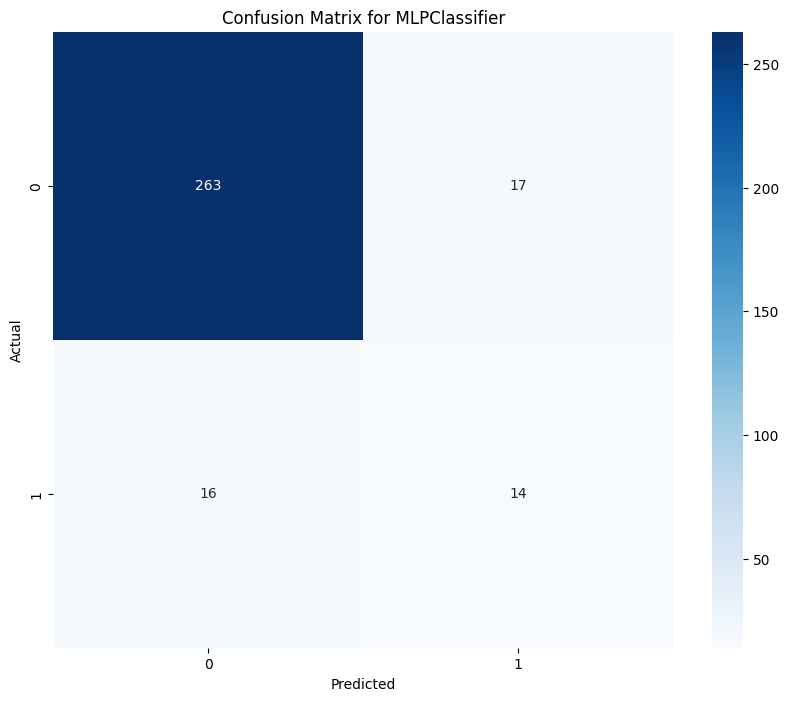

Classification Report for HistGradientBoostingClassifier:
              precision    recall  f1-score   support

           0      0.942     0.982     0.962       280
           1      0.722     0.433     0.542        30

    accuracy                          0.929       310
   macro avg      0.832     0.708     0.752       310
weighted avg      0.921     0.929     0.921       310



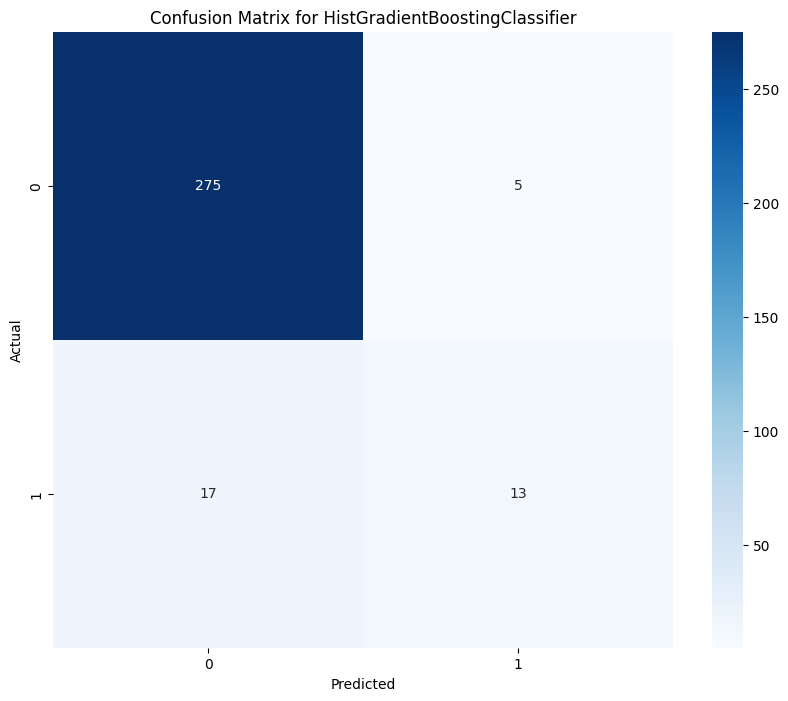

Classification Report for LinearDiscriminantAnalysis:
              precision    recall  f1-score   support

           0      0.926     0.675     0.781       280
           1      0.142     0.500     0.221        30

    accuracy                          0.658       310
   macro avg      0.534     0.588     0.501       310
weighted avg      0.851     0.658     0.727       310



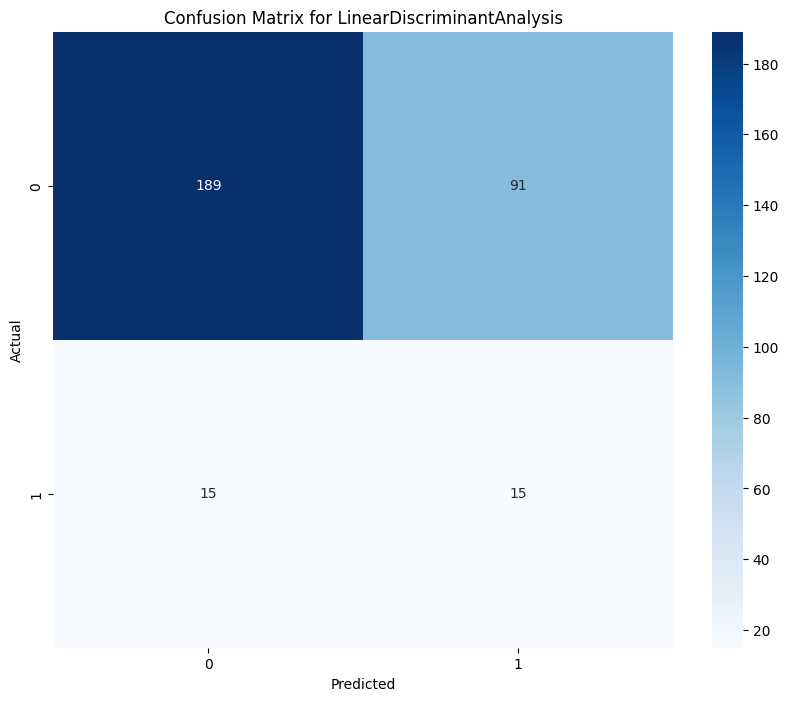

Classification Report for QuadraticDiscriminantAnalysis:
              precision    recall  f1-score   support

           0      0.920     0.532     0.674       280
           1      0.115     0.567     0.191        30

    accuracy                          0.535       310
   macro avg      0.517     0.549     0.433       310
weighted avg      0.842     0.535     0.627       310



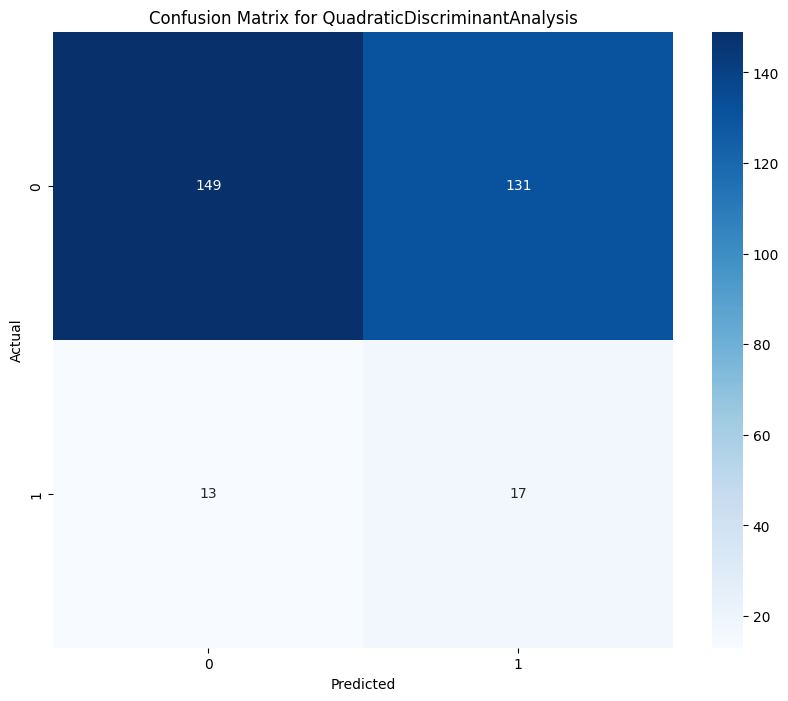

                             Model  F1 Score (Weighted)  F1 Score (Macro)  \
0             KNeighborsClassifier             0.759153          0.544830   
1           RandomForestClassifier             0.919865          0.737616   
2                    XGBClassifier             0.920906          0.751603   
3                   LGBMClassifier             0.914409          0.724444   
4               LogisticRegression             0.716974          0.492560   
5                              SVC             0.838873          0.611435   
6           DecisionTreeClassifier             0.868338          0.654298   
7       GradientBoostingClassifier             0.874970          0.600818   
8               AdaBoostClassifier             0.844870          0.584155   
9                BaggingClassifier             0.905742          0.728391   
10            ExtraTreesClassifier             0.915518          0.738947   
11              CatBoostClassifier             0.899523          0.676522   

In [33]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    BaggingClassifier,
    VotingClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import RidgeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from imblearn.over_sampling import SMOTE
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

# Initialize models
models = {
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=0),
    "XGBoost": XGBClassifier(random_state=0, use_label_encoder=False, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(random_state=0),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Support Vector Classifier": SVC(probability=True),
    "Decision Tree": DecisionTreeClassifier(random_state=0),
    "Gradient Boosting": GradientBoostingClassifier(random_state=0),
    "AdaBoost": AdaBoostClassifier(random_state=0),
    "Bagging": BaggingClassifier(random_state=0),
    "Extra Trees": ExtraTreesClassifier(random_state=0),
    "CatBoost": CatBoostClassifier(silent=True),  # Set silent=True to suppress output during training
    "Naive Bayes": GaussianNB(),
    "Neural Network": MLPClassifier(max_iter=1000),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(random_state=0),
    "Linear Discriminant Analysis": LinearDiscriminantAnalysis(),
    "Quadratic Discriminant Analysis": QuadraticDiscriminantAnalysis(),
}

# List to store evaluation metrics for each model
metrics = []

# Function to evaluate each model
def evaluate_model(model, X_test_processed, y_test):
    # Fit the model
    model.fit(X_train_resampled, y_train_resampled)

    # Get predicted probabilities for the positive class
    y_probs = model.predict_proba(X_test_processed)[:, 1]

    # Make predictions using a default threshold of 0.5
    y_pred = (y_probs >= 0.5).astype(int)

    # Calculate F1 scores and accuracy
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    f1_macro = f1_score(y_test, y_pred, average='macro')
    accuracy = accuracy_score(y_test, y_pred)

    # Append metrics to the list
    metrics.append({
        "Model": model.__class__.__name__,
        "F1 Score (Weighted)": f1_weighted,
        "F1 Score (Macro)": f1_macro,
        "Accuracy": accuracy
    })

    # Print classification report
    print(f"Classification Report for {model.__class__.__name__}:")
    print(classification_report(y_test, y_pred, digits=3))

    # Plot the confusion matrix heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix for {model.__class__.__name__}')
    plt.show()

# Evaluate all models
for name, model in models.items():
    evaluate_model(model, X_test_processed, y_test)

# Create a DataFrame from the metrics list
metrics_df = pd.DataFrame(metrics)

# Print the DataFrame
print(metrics_df)


### Geometric Means

Classification Report for KNeighborsClassifier:
              precision    recall  f1-score   support

           0      0.944     0.907     0.925       280
           1      0.366     0.500     0.423        30

    accuracy                          0.868       310
   macro avg      0.655     0.704     0.674       310
weighted avg      0.888     0.868     0.877       310



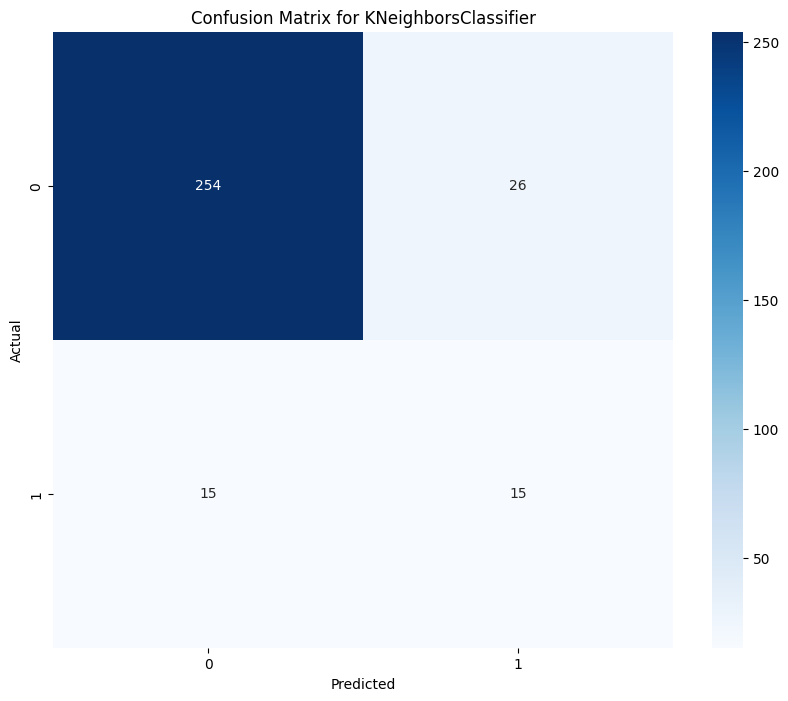

Classification Report for RandomForestClassifier:
              precision    recall  f1-score   support

           0      0.960     0.864     0.910       280
           1      0.345     0.667     0.455        30

    accuracy                          0.845       310
   macro avg      0.653     0.765     0.682       310
weighted avg      0.901     0.845     0.866       310



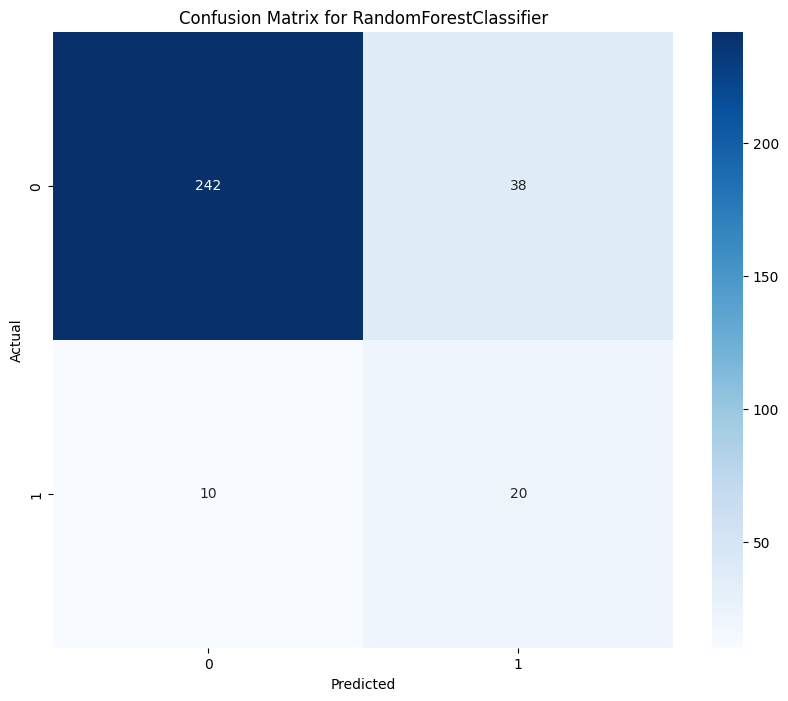

Classification Report for XGBClassifier:
              precision    recall  f1-score   support

           0      0.970     0.804     0.879       280
           1      0.295     0.767     0.426        30

    accuracy                          0.800       310
   macro avg      0.632     0.785     0.652       310
weighted avg      0.905     0.800     0.835       310



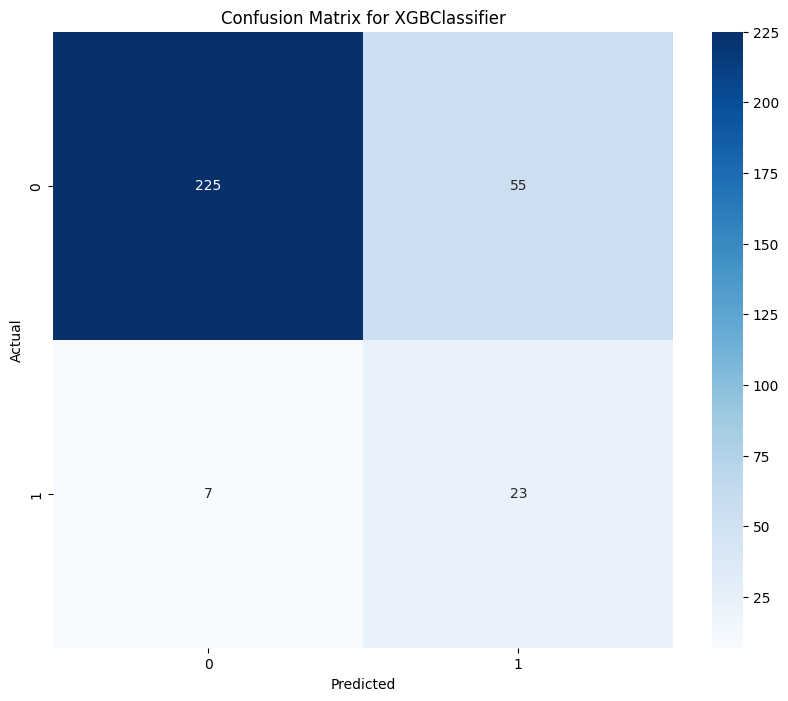

[LightGBM] [Info] Number of positive: 1086, number of negative: 1093
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001294 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2703
[LightGBM] [Info] Number of data points in the train set: 2179, number of used features: 47
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.498394 -> initscore=-0.006425
[LightGBM] [Info] Start training from score -0.006425
Classification Report for LGBMClassifier:
              precision    recall  f1-score   support

           0      0.969     0.775     0.861       280
           1      0.267     0.767     0.397        30

    accuracy                          0.774       310
   macro avg      0.618     0.771     0.629       310
weighted avg      0.901     0.774     0.816       310



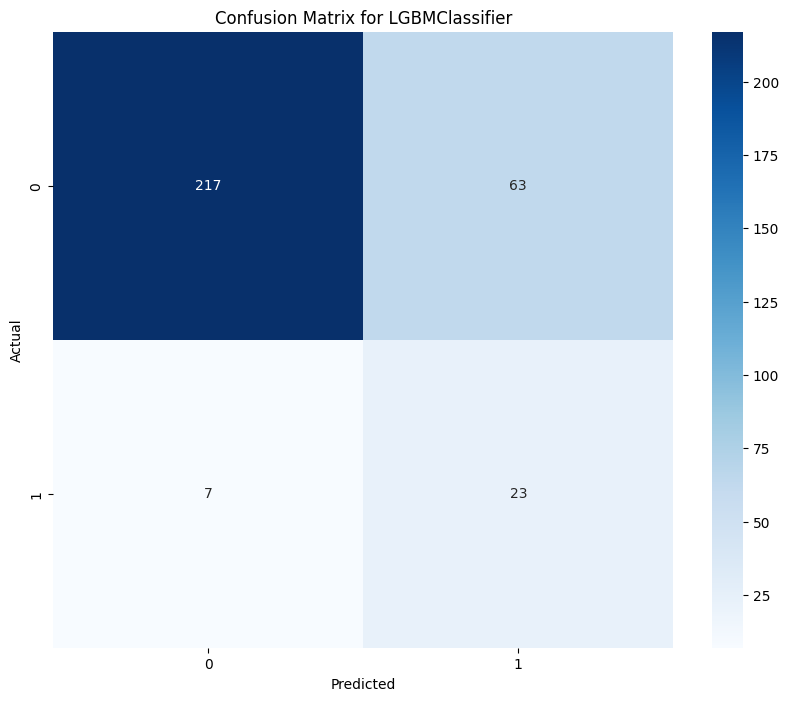

Classification Report for LogisticRegression:
              precision    recall  f1-score   support

           0      0.950     0.611     0.743       280
           1      0.162     0.700     0.263        30

    accuracy                          0.619       310
   macro avg      0.556     0.655     0.503       310
weighted avg      0.874     0.619     0.697       310



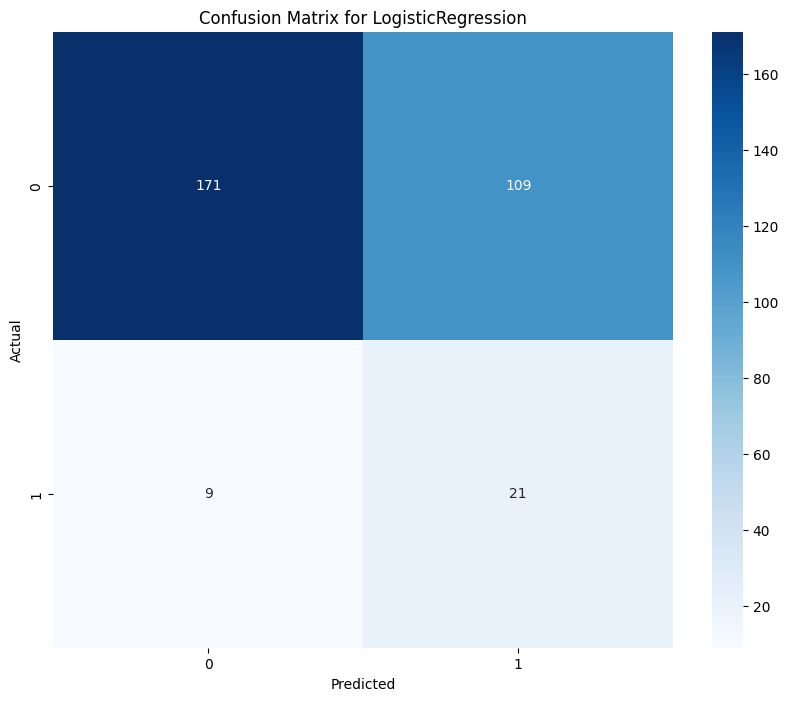

Classification Report for SVC:
              precision    recall  f1-score   support

           0      0.964     0.582     0.726       280
           1      0.170     0.800     0.281        30

    accuracy                          0.603       310
   macro avg      0.567     0.691     0.503       310
weighted avg      0.888     0.603     0.683       310



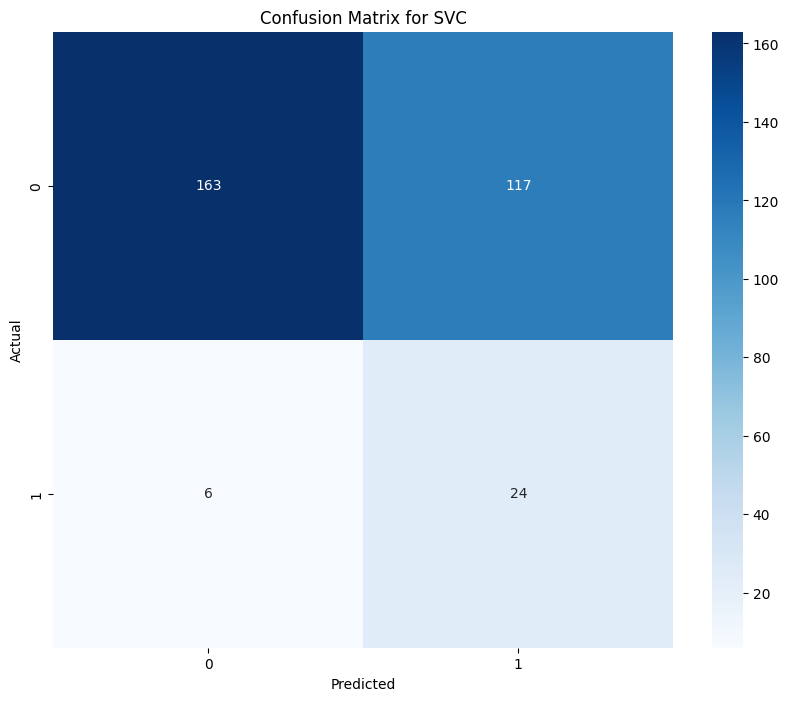

Classification Report for DecisionTreeClassifier:
              precision    recall  f1-score   support

           0      0.940     0.900     0.920       280
           1      0.333     0.467     0.389        30

    accuracy                          0.858       310
   macro avg      0.637     0.683     0.654       310
weighted avg      0.882     0.858     0.868       310



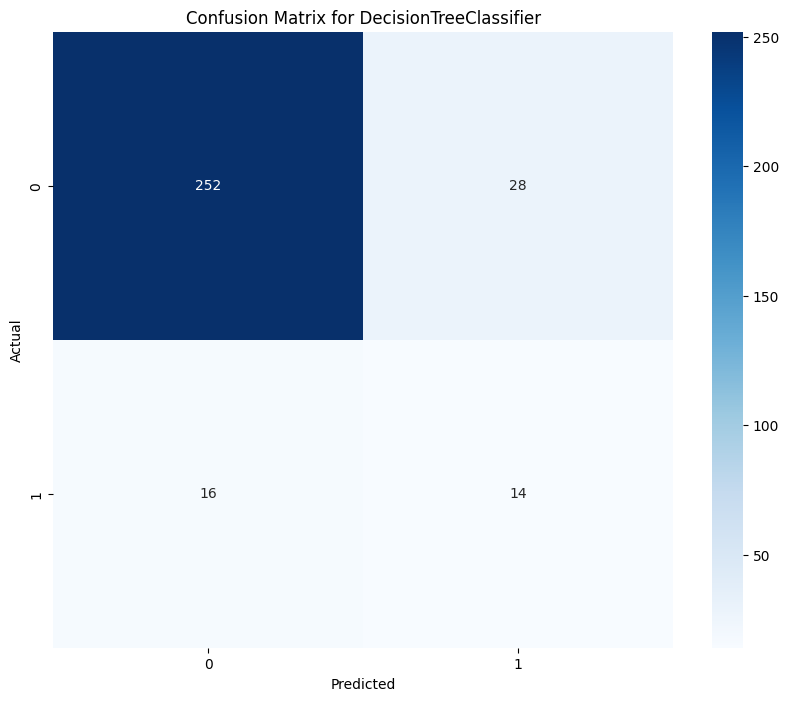

Classification Report for GradientBoostingClassifier:
              precision    recall  f1-score   support

           0      0.963     0.646     0.774       280
           1      0.189     0.767     0.303        30

    accuracy                          0.658       310
   macro avg      0.576     0.707     0.538       310
weighted avg      0.888     0.658     0.728       310



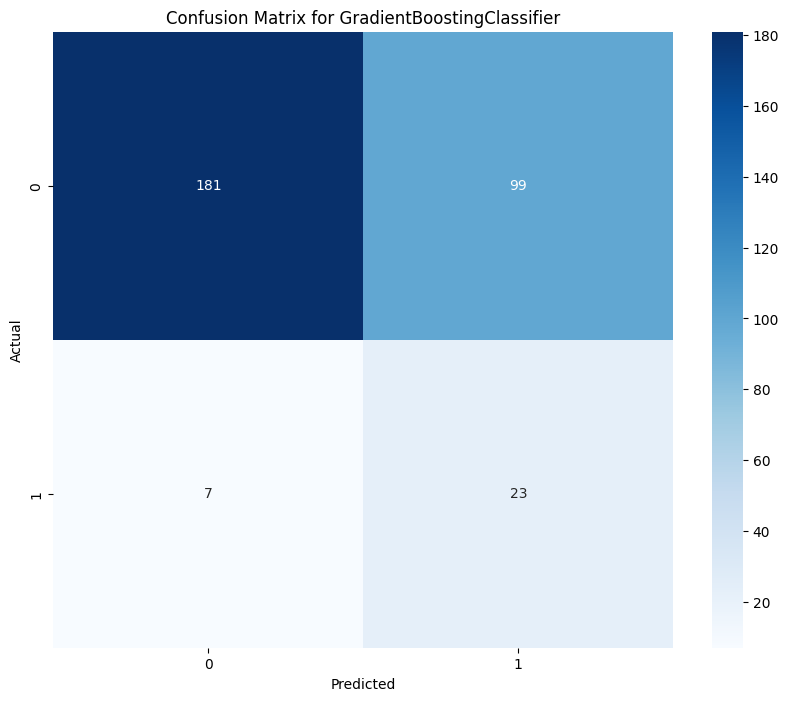

Classification Report for AdaBoostClassifier:
              precision    recall  f1-score   support

           0      0.956     0.539     0.689       280
           1      0.151     0.767     0.253        30

    accuracy                          0.561       310
   macro avg      0.554     0.653     0.471       310
weighted avg      0.878     0.561     0.647       310



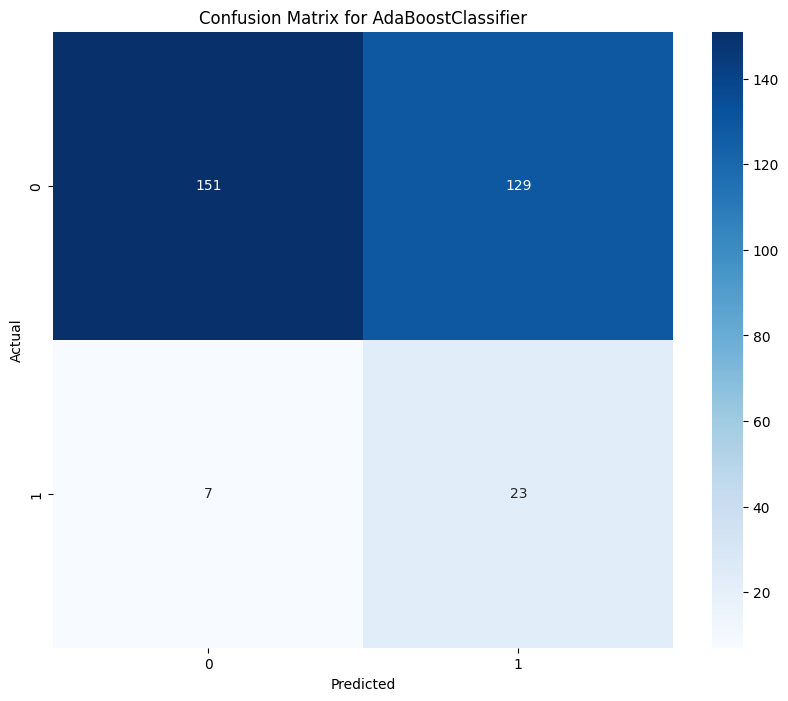

Classification Report for BaggingClassifier:
              precision    recall  f1-score   support

           0      0.963     0.825     0.888       280
           1      0.300     0.700     0.420        30

    accuracy                          0.813       310
   macro avg      0.631     0.762     0.654       310
weighted avg      0.898     0.813     0.843       310



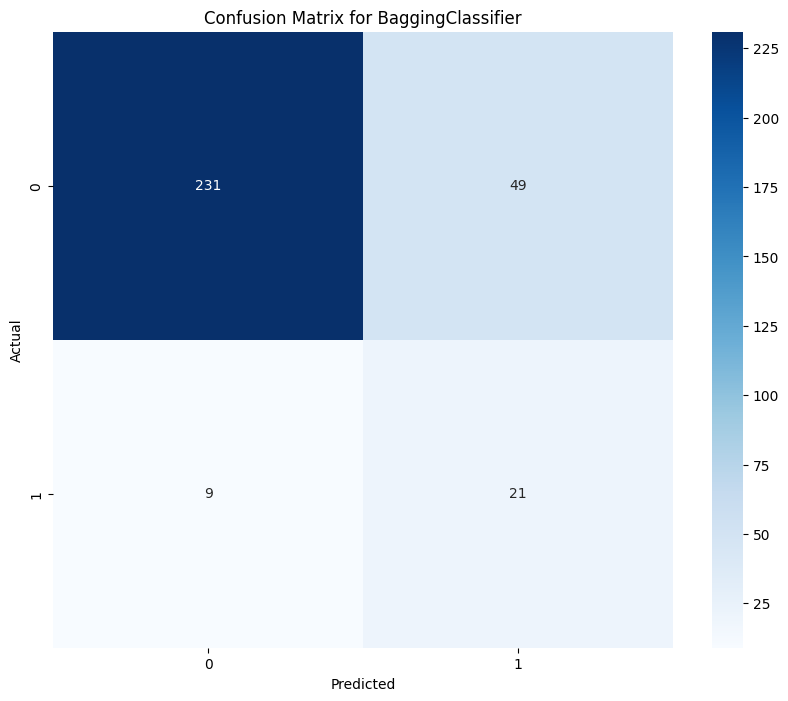

Classification Report for ExtraTreesClassifier:
              precision    recall  f1-score   support

           0      0.955     0.839     0.894       280
           1      0.297     0.633     0.404        30

    accuracy                          0.819       310
   macro avg      0.626     0.736     0.649       310
weighted avg      0.892     0.819     0.846       310



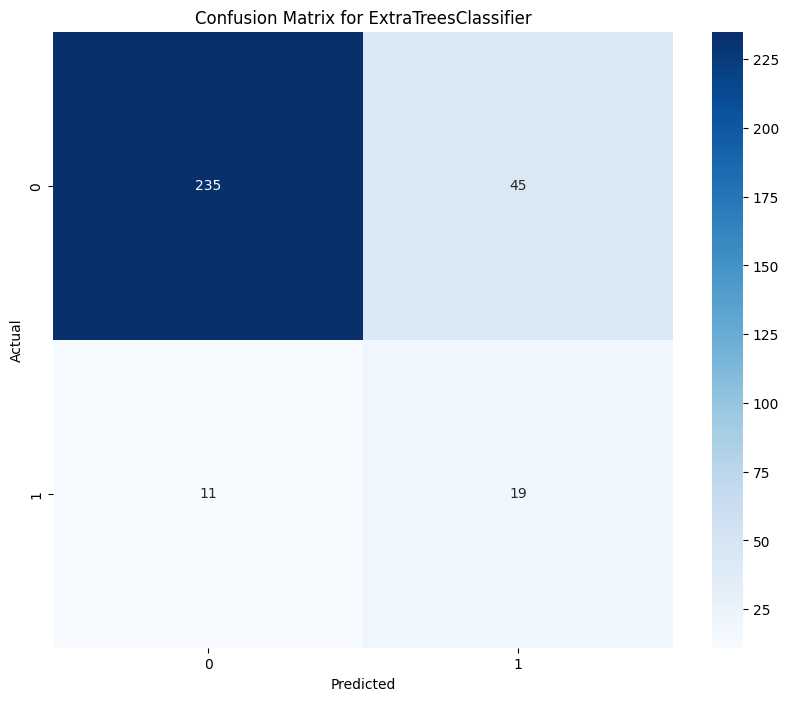

Classification Report for CatBoostClassifier:
              precision    recall  f1-score   support

           0      0.973     0.764     0.856       280
           1      0.267     0.800     0.400        30

    accuracy                          0.768       310
   macro avg      0.620     0.782     0.628       310
weighted avg      0.904     0.768     0.812       310



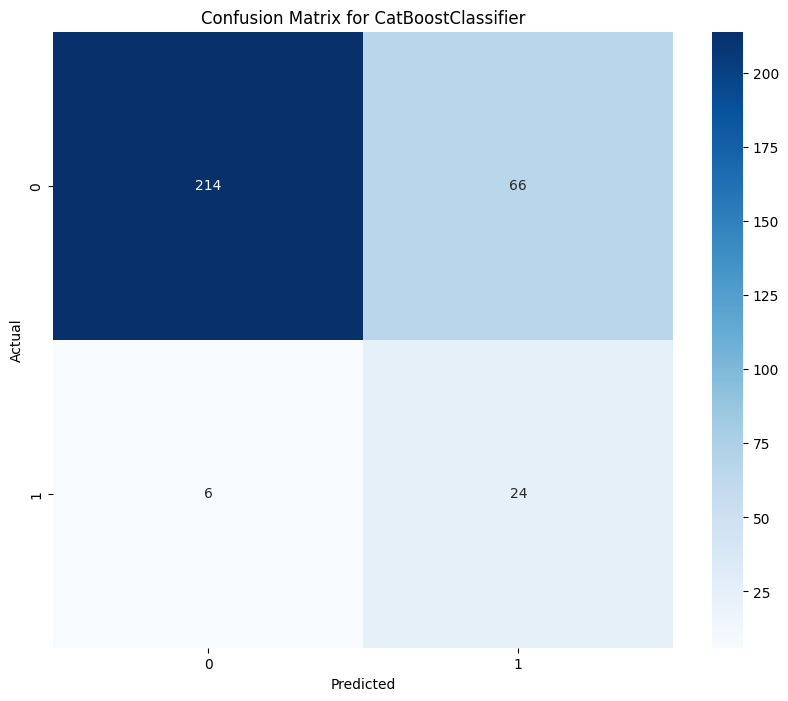

Classification Report for GaussianNB:
              precision    recall  f1-score   support

           0      0.955     0.536     0.686       280
           1      0.150     0.767     0.251        30

    accuracy                          0.558       310
   macro avg      0.553     0.651     0.469       310
weighted avg      0.878     0.558     0.644       310



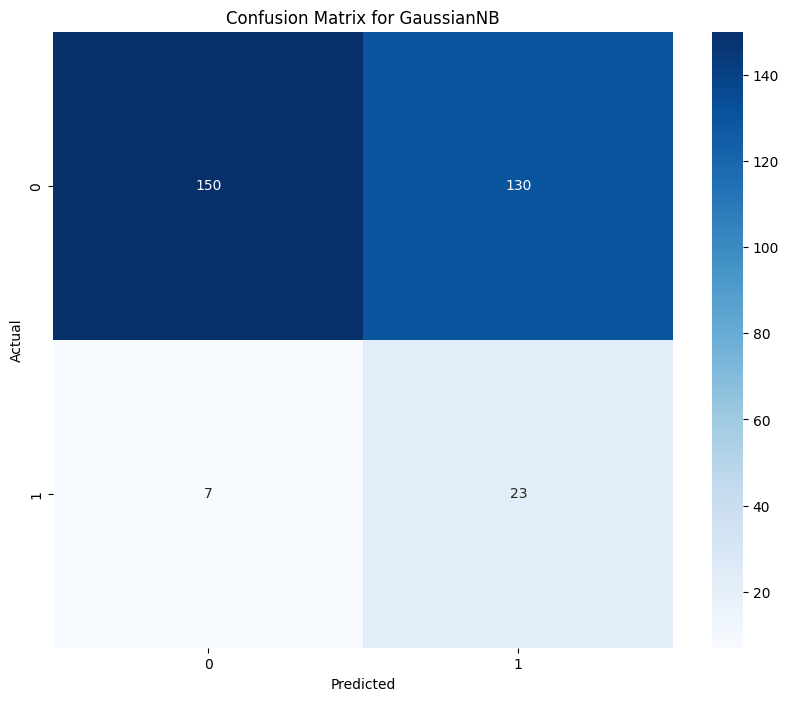

Classification Report for MLPClassifier:
              precision    recall  f1-score   support

           0      0.951     0.904     0.927       280
           1      0.386     0.567     0.459        30

    accuracy                          0.871       310
   macro avg      0.669     0.735     0.693       310
weighted avg      0.896     0.871     0.882       310



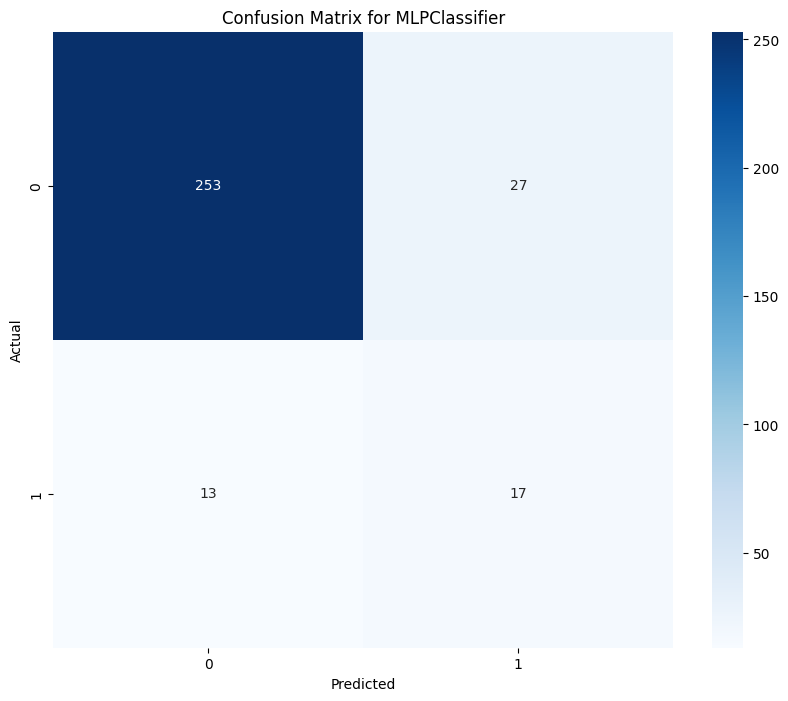

Classification Report for HistGradientBoostingClassifier:
              precision    recall  f1-score   support

           0      0.961     0.875     0.916       280
           1      0.364     0.667     0.471        30

    accuracy                          0.855       310
   macro avg      0.662     0.771     0.693       310
weighted avg      0.903     0.855     0.873       310



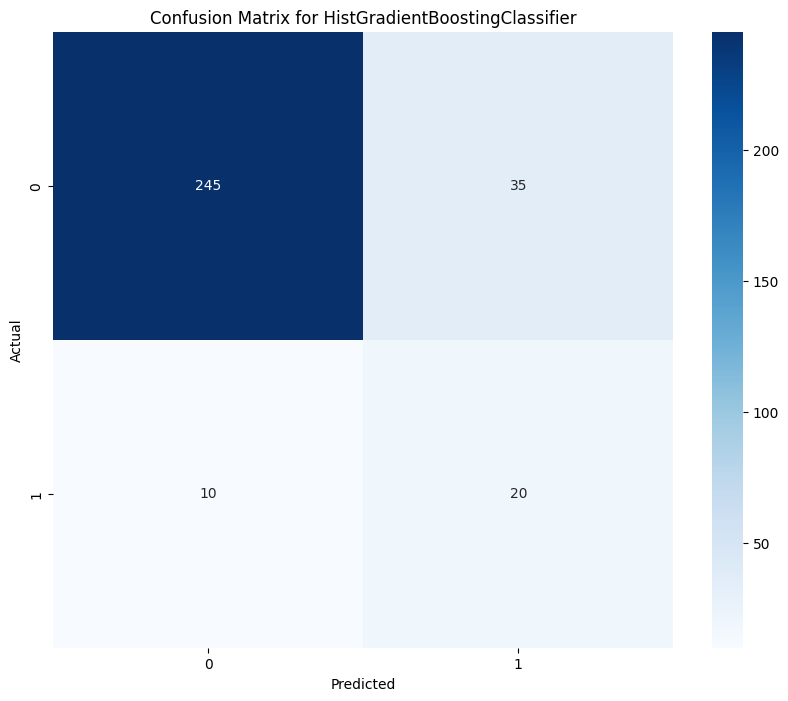

Classification Report for LinearDiscriminantAnalysis:
              precision    recall  f1-score   support

           0      0.952     0.571     0.714       280
           1      0.155     0.733     0.256        30

    accuracy                          0.587       310
   macro avg      0.554     0.652     0.485       310
weighted avg      0.875     0.587     0.670       310



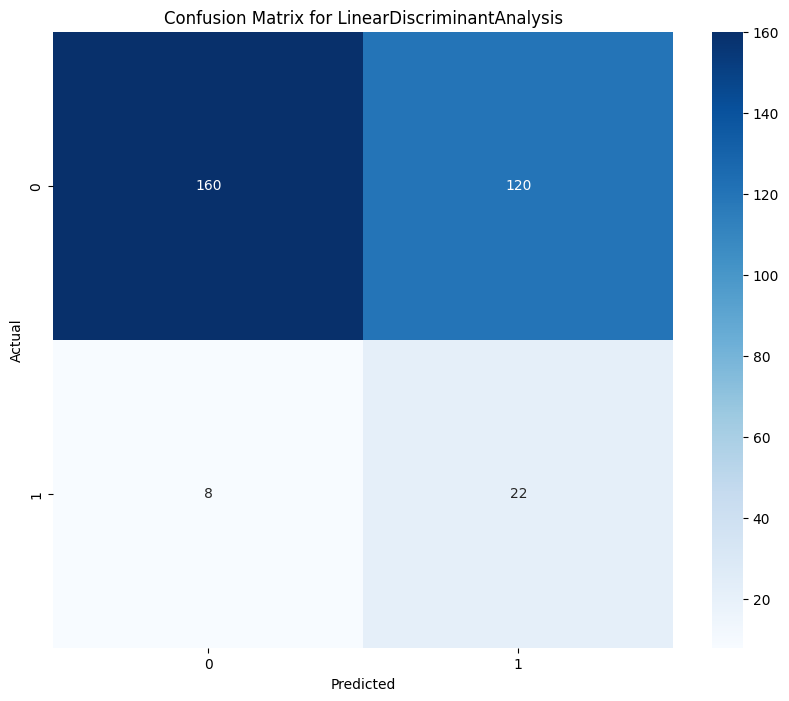

Classification Report for QuadraticDiscriminantAnalysis:
              precision    recall  f1-score   support

           0      0.940     0.504     0.656       280
           1      0.131     0.700     0.221        30

    accuracy                          0.523       310
   macro avg      0.536     0.602     0.438       310
weighted avg      0.862     0.523     0.614       310



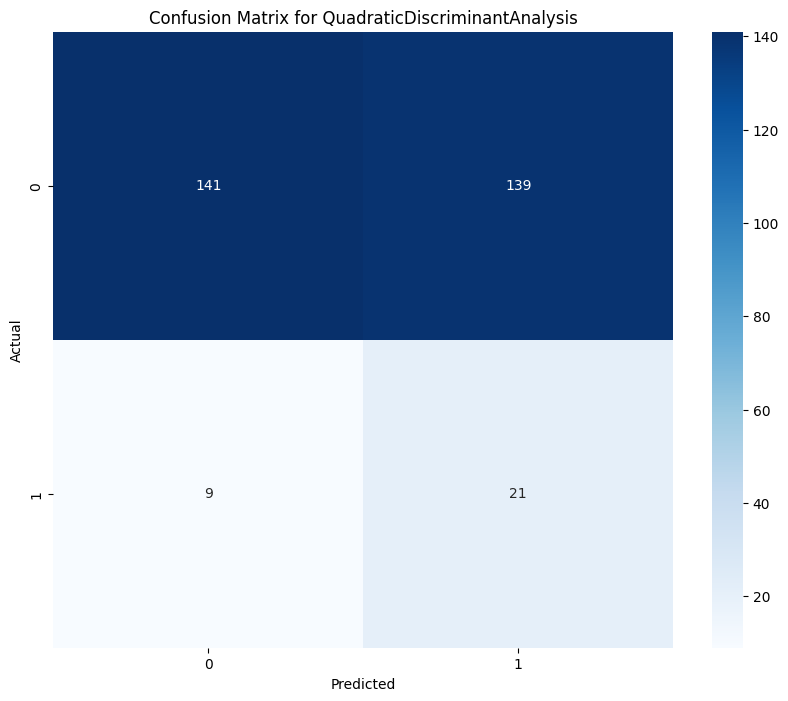

In [34]:
# Calculate geometric mean for each threshold
def geometric_mean(sensitivity, specificity):
    return np.sqrt(sensitivity * specificity)

# Initialize models
models = {
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=0),
    "XGBoost": XGBClassifier(random_state=0, use_label_encoder=False, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(random_state=0),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Support Vector Classifier": SVC(probability=True),
    "Decision Tree": DecisionTreeClassifier(random_state=0),
    "Gradient Boosting": GradientBoostingClassifier(random_state=0),
    "AdaBoost": AdaBoostClassifier(random_state=0),
    "Bagging": BaggingClassifier(random_state=0),
    "Extra Trees": ExtraTreesClassifier(random_state=0),
    "CatBoost": CatBoostClassifier(silent=True),  # Set silent=True to suppress output during training
    "Naive Bayes": GaussianNB(),
    "Neural Network": MLPClassifier(max_iter=1000),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(random_state=0),
    "Linear Discriminant Analysis": LinearDiscriminantAnalysis(),
    "Quadratic Discriminant Analysis": QuadraticDiscriminantAnalysis(),
}

# Function to evaluate each model
def evaluate_model(model, X_test_processed, y_test):
    # Fit the model
    model.fit(X_train_resampled, y_train_resampled)

    # Get predicted probabilities for the positive class
    y_probs = model.predict_proba(X_test_processed)[:, 1]

    # Calculate the ROC curve points
    fpr, tpr, thresholds = roc_curve(y_test, y_probs, pos_label=1)

    # Calculate specificity (1 - FPR)
    specificity = 1 - fpr

    # Calculate geometric mean for each threshold
    gmeans = [geometric_mean(tpr[i], specificity[i]) for i in range(len(tpr))]

    # Find the threshold that gives the best geometric mean
    optimal_idx = np.argmax(gmeans)
    optimal_threshold = thresholds[optimal_idx]

    # Make predictions using the optimal threshold
    y_pred = (y_probs >= optimal_threshold).astype(int)

    # Print classification report
    print(f"Classification Report for {model.__class__.__name__}:")
    print(classification_report(y_test, y_pred, digits=3))

    # Plot the confusion matrix heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix for {model.__class__.__name__}')
    plt.show()

# Evaluate all models
for name, model in models.items():
    evaluate_model(model, X_test_processed, y_test)


Classification Report for CatBoostClassifier:
              precision    recall  f1-score   support

           0      0.973     0.764     0.856       280
           1      0.267     0.800     0.400        30

    accuracy                          0.768       310
   macro avg      0.620     0.782     0.628       310
weighted avg      0.904     0.768     0.812       310



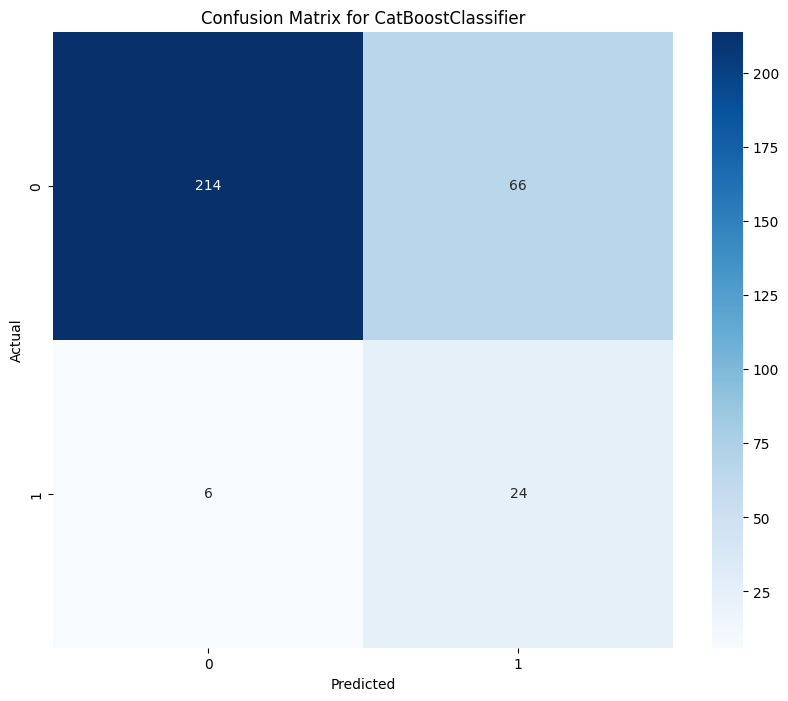

In [ ]:
# Calculate geometric mean for each threshold
def geometric_mean(sensitivity, specificity):
    return np.sqrt(sensitivity * specificity)

# Initialize models
models = {
    "CatBoost": CatBoostClassifier(random_state=0, silent=True)
}

# Function to evaluate each model
def evaluate_model(model, X_test_processed, y_test):
    # Fit the model
    model.fit(X_train_resampled, y_train_resampled)

    # Get predicted probabilities for the positive class
    y_probs = model.predict_proba(X_test_processed)[:, 1]

    # Calculate the ROC curve points
    fpr, tpr, thresholds = roc_curve(y_test, y_probs, pos_label=1)

    # Calculate specificity (1 - FPR)
    specificity = 1 - fpr

    # Calculate geometric mean for each threshold
    gmeans = [geometric_mean(tpr[i], specificity[i]) for i in range(len(tpr))]

    # Find the threshold that gives the best geometric mean
    optimal_idx = np.argmax(gmeans)
    optimal_threshold = thresholds[optimal_idx]

    # Make predictions using the optimal threshold
    y_pred = (y_probs >= optimal_threshold).astype(int)

    # Print classification report
    print(f"Classification Report for {model.__class__.__name__}:")
    print(classification_report(y_test, y_pred, digits=3))

    # Plot the confusion matrix heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix for {model.__class__.__name__}')
    plt.show()

# Evaluate all models
for name, model in models.items():
    evaluate_model(model, X_test_processed, y_test)


### Class Weight

In [ ]:
models = {
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=0),
    "XGBoost": XGBClassifier(random_state=0, use_label_encoder=False, eval_metric='logloss'),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Support Vector Classifier": SVC(probability=True, class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', random_state=0),
    "Extra Trees": ExtraTreesClassifier(class_weight='balanced', random_state=0)
}

### Voting Classif

[LightGBM] [Info] Number of positive: 1086, number of negative: 1093
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001170 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2703
[LightGBM] [Info] Number of data points in the train set: 2179, number of used features: 47
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.498394 -> initscore=-0.006425
[LightGBM] [Info] Start training from score -0.006425
Classification Report for Voting Classifier:
              precision    recall  f1-score   support

           0      0.956     0.939     0.948       280
           1      0.514     0.600     0.554        30

    accuracy                          0.906       310
   macro avg      0.735     0.770     0.751       310
weighted avg      0.914     0.906     0.910       310



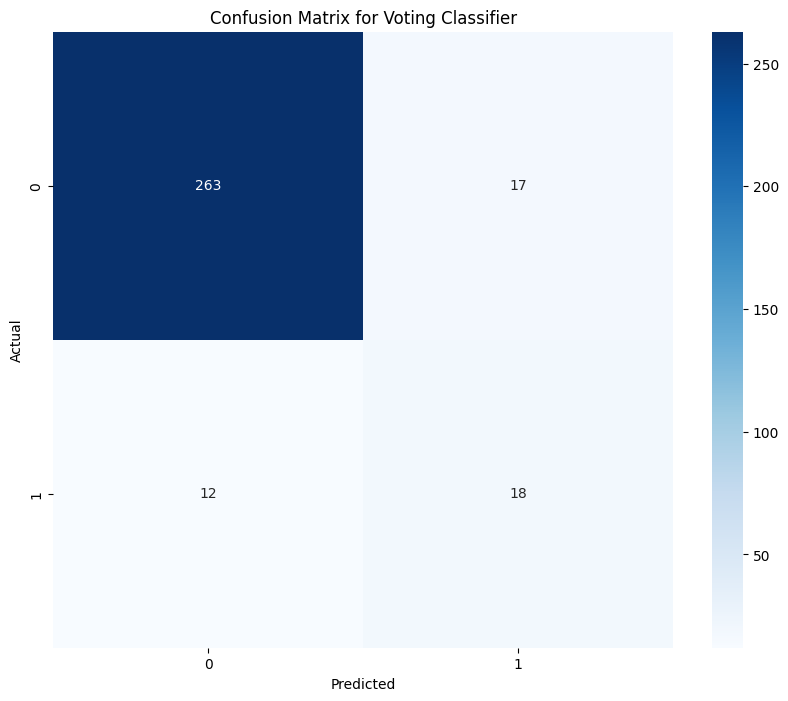

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize individual models
knn = KNeighborsClassifier()
rf = RandomForestClassifier(random_state=0)
xgb = XGBClassifier(random_state=0, use_label_encoder=False, eval_metric='logloss')
lgbm = LGBMClassifier(random_state=0)

# Create a voting classifier with soft voting (average of predicted probabilities)
voting_clf = VotingClassifier(
    estimators=[
        ('knn', knn),
        ('rf', rf),
        ('xgb', xgb),
        ('lgbm', lgbm)
    ],
    voting='soft'  # Use 'hard' for majority voting or 'soft' for average of probabilities
)

# Train the voting classifier on the training set
voting_clf.fit(X_train_resampled, y_train_resampled)

# Predict probabilities on the test set for the positive class
y_probs_voting = voting_clf.predict_proba(X_test_processed)[:, 1]

# Calculate the ROC curve and geometric mean for each threshold
fpr, tpr, thresholds = roc_curve(y_test, y_probs_voting, pos_label=1)
specificity = 1 - fpr
gmeans = [geometric_mean(tpr[i], specificity[i]) for i in range(len(tpr))]

# Find the optimal threshold based on the best geometric mean
optimal_idx = np.argmax(gmeans)
optimal_threshold = thresholds[optimal_idx]

# Make predictions using the optimal threshold
y_pred_voting = (y_probs_voting >= optimal_threshold).astype(int)

# Print classification report
print("Classification Report for Voting Classifier:")
print(classification_report(y_test, y_pred_voting, digits=3))

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_pred_voting), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Voting Classifier')
plt.show()


Without gmeans

[LightGBM] [Info] Number of positive: 1086, number of negative: 1093
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001126 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2703
[LightGBM] [Info] Number of data points in the train set: 2179, number of used features: 47
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.498394 -> initscore=-0.006425
[LightGBM] [Info] Start training from score -0.006425
Classification Report for Voting Classifier:
              precision    recall  f1-score   support

           0      0.941     0.975     0.958       280
           1      0.650     0.433     0.520        30

    accuracy                          0.923       310
   macro avg      0.796     0.704     0.739       310
weighted avg      0.913     0.923     0.916       310



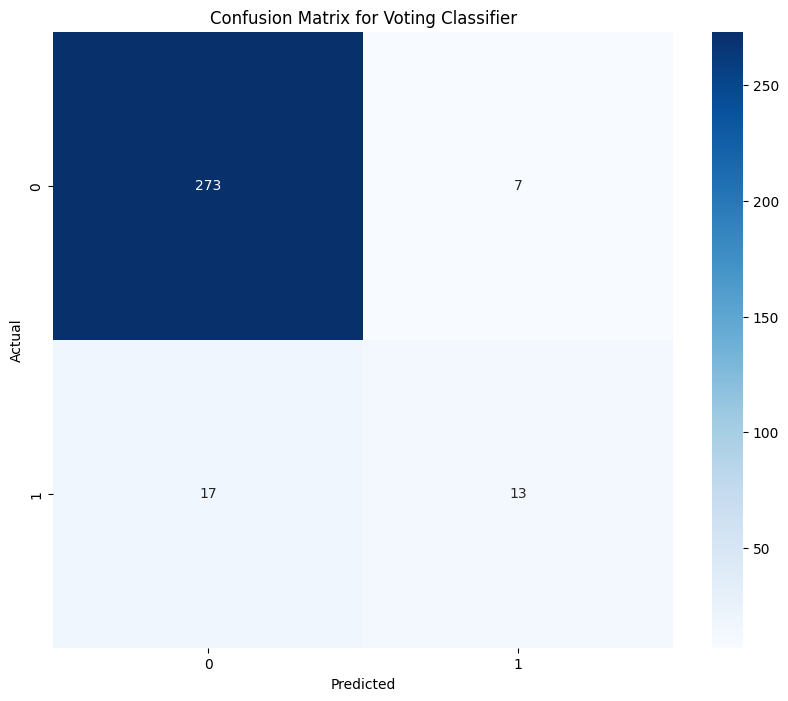

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize individual models
knn = KNeighborsClassifier()
rf = RandomForestClassifier(random_state=0)
xgb = XGBClassifier(random_state=0, use_label_encoder=False, eval_metric='logloss')
lgbm = LGBMClassifier(random_state=0)

# Create a voting classifier with soft voting (average of predicted probabilities)
voting_clf = VotingClassifier(
    estimators=[
        ('knn', knn),
        ('rf', rf),
        ('xgb', xgb),
        ('lgbm', lgbm)
    ],
    voting='soft'  # Use 'hard' for majority voting or 'soft' for average of probabilities
)

# Train the voting classifier on the training set
voting_clf.fit(X_train_resampled, y_train_resampled)

# Predict probabilities on the test set for the positive class
y_probs_voting = voting_clf.predict_proba(X_test_processed)[:, 1]

# Apply a 0.5 threshold for classification
y_pred_voting = (y_probs_voting >= 0.5).astype(int)

# Print classification report
print("Classification Report for Voting Classifier:")
print(classification_report(y_test, y_pred_voting, digits=3))

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_pred_voting), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Voting Classifier')
plt.show()


### Ensemble

[LightGBM] [Info] Number of positive: 1086, number of negative: 1093
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001141 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2703
[LightGBM] [Info] Number of data points in the train set: 2179, number of used features: 47
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.498394 -> initscore=-0.006425
[LightGBM] [Info] Start training from score -0.006425
[LightGBM] [Info] Number of positive: 869, number of negative: 874
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000941 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2579
[LightGBM] [Info] Number of data points in the train set: 1743, number of used features: 46
[LightGBM] [Info] [binary:

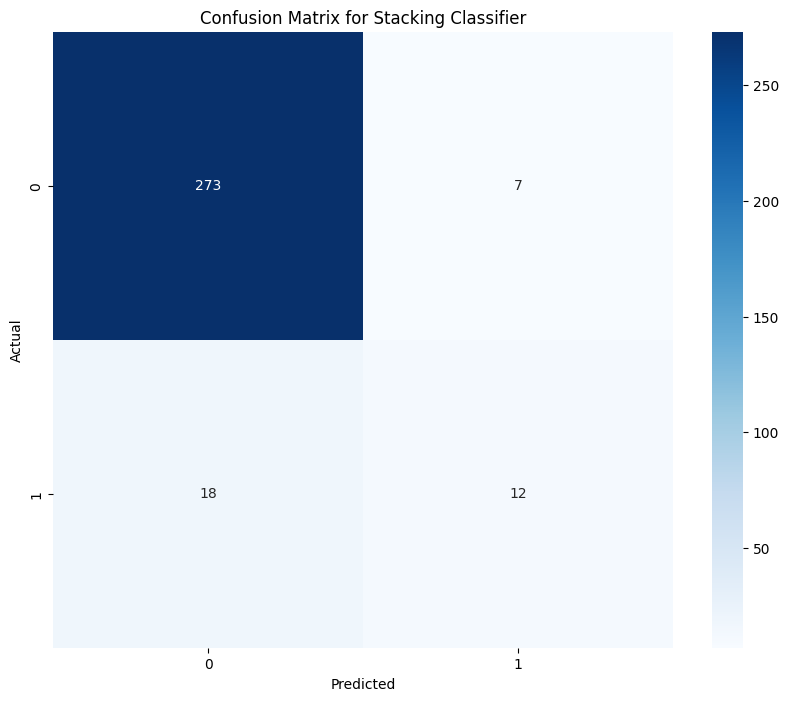

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Define the base models
base_models = [
    ('knn', KNeighborsClassifier()),
    ('rf', RandomForestClassifier(random_state=0)),
    ('xgb', XGBClassifier(random_state=0, use_label_encoder=False, eval_metric='logloss')),
    ('lgbm', LGBMClassifier(random_state=0))
]

# Define the final estimator (meta-classifier)
final_estimator = LogisticRegression()

# Create the stacking classifier
stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=final_estimator,
    stack_method='predict_proba'  # Use probabilities as inputs to the meta-classifier
)

# Train the stacking classifier on the training data
stacking_clf.fit(X_train_resampled, y_train_resampled)

# Predict on the test set using the stacking classifier
y_pred_stacking = stacking_clf.predict(X_test_processed)

# Print classification report
print("Classification Report for Stacking Classifier:")
print(classification_report(y_test, y_pred_stacking, digits=3))

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_pred_stacking), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Stacking Classifier')
plt.show()


### Gaussian Proccess

In [ ]:
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the Gaussian Process Classifier with a Radial Basis Function kernel
kernel = 1.0 * RBF(length_scale=1.0)
gpc = GaussianProcessClassifier(kernel=kernel)

# Train the Gaussian Process Classifier on the training set
gpc.fit(X_train_resampled, y_train_resampled)

# Predict probabilities on the test set
y_probs_gpc = gpc.predict_proba(X_test_processed)[:, 1]

# Make predictions using a default threshold of 0.5
y_pred_gpc = (y_probs_gpc >= 0.5).astype(int)

# Print classification report
print("Classification Report for Gaussian Process Classifier:")
print(classification_report(y_test, y_pred_gpc, digits=3))

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_pred_gpc), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Gaussian Process Classifier')
plt.show()


With geomeans

In [28]:
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Initialize the Gaussian Process Classifier with a Radial Basis Function kernel
kernel = 1.0 * RBF(length_scale=1.0)
gpc = GaussianProcessClassifier(kernel=kernel)

# Train the Gaussian Process Classifier on the training set
gpc.fit(X_train_resampled, y_train_resampled)

# Predict probabilities on the test set
y_probs_gpc = gpc.predict_proba(X_test_processed)[:, 1]

# Calculate the ROC curve and geometric mean for each threshold
fpr, tpr, thresholds = roc_curve(y_test, y_probs_gpc, pos_label=1)
specificity = 1 - fpr
gmeans = [geometric_mean(tpr[i], specificity[i]) for i in range(len(tpr))]

# Find the optimal threshold based on the best geometric mean
optimal_idx = np.argmax(gmeans)
optimal_threshold = thresholds[optimal_idx]

# Make predictions using the optimal threshold
y_pred_gpc = (y_probs_gpc >= optimal_threshold).astype(int)

# Print classification report
print("Classification Report for Gaussian Process Classifier:")
print(classification_report(y_test, y_pred_gpc, digits=3))

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_pred_gpc), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Gaussian Process Classifier')
plt.show()


KeyboardInterrupt: 

## Metode Neural Network

In [ ]:
resampled_df = pd.concat([X_train_resampled_df, y_train_resampled_df], axis=1)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_resampled), y=y_train_resampled)
class_weights_dict = {0: class_weights[0], 1: class_weights[1]}


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LeakyReLU, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

# Define the neural network model with optimizations
model = Sequential([
    Dense(512, input_dim=X_train_resampled.shape[1], kernel_regularizer=l2(0.001)),  # L2 regularization
    BatchNormalization(),  # Batch Normalization
    LeakyReLU(alpha=0.1),
    Dropout(0.4),

    Dense(256, kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.4),

    Dense(128, activation='tanh', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(16, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(8, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model with Adam optimizer and learning rate schedule
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Define callbacks for early stopping and learning rate reduction
early_stopping = EarlyStopping(monitor='val_loss', patience=100, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

# Train the model with class weights and callbacks
history = model.fit(
    X_train_resampled, y_train_resampled,
    epochs=300, batch_size=32,
    validation_split=0.2,
    verbose=1,
    class_weight=class_weights_dict,
    callbacks=[early_stopping, reduce_lr]
)

# Evaluate the model on the test set
y_pred_probs = model.predict(X_test_processed)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)

# Calculate specificity (1 - false positive rate)
specificity = 1 - fpr

# Calculate geometric mean for each threshold
gmeans = np.sqrt(tpr * specificity)

# Find the optimal threshold
optimal_idx = np.argmax(gmeans)
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal Threshold based on Geometric Mean: {optimal_threshold}")

# Make predictions based on the optimal threshold
y_pred = (y_pred_probs >= optimal_threshold).astype(int)

# Evaluate the new predictions
print("Classification Report:")
print(classification_report(y_test, y_pred,digits=3))

# Plot the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Plot the ROC curve with the optimal point marked
plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, label='ROC curve')
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], marker='o', color='red', label=f'Optimal Threshold ({optimal_threshold:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# Plot training & validation accuracy values
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


Run pertama tidak menggunakan random seed sehingga apabila di run ulang tidak bisa menghasilkan output yang sama.

## Pemilihan Model Terbaik

In [ ]:
y_train_resampled_df = pd.DataFrame(y_train_resampled, columns=['label'])

In [ ]:
from sklearn.metrics import roc_curve, classification_report, confusion_matrix
from catboost import CatBoostClassifier
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Function to calculate geometric mean for each threshold
def geometric_mean(sensitivity, specificity):
    return np.sqrt(sensitivity * specificity)

# Initialize model
model = CatBoostClassifier(random_state=0, silent=True)

# Function to evaluate the model and display feature importance
def evaluate_model(model, X_train_resampled_df, y_train_resampled_df, X_test_processed, y_test):
    # Fit the model
    model.fit(X_train_resampled_df, y_train_resampled_df)

    # Get predicted probabilities for the positive class
    y_probs = model.predict_proba(X_test_processed)[:, 1]

    # Calculate the ROC curve points
    fpr, tpr, thresholds = roc_curve(y_test, y_probs, pos_label=1)

    # Calculate specificity (1 - FPR)
    specificity = 1 - fpr

    # Calculate geometric mean for each threshold
    gmeans = [geometric_mean(tpr[i], specificity[i]) for i in range(len(tpr))]

    # Find the threshold that gives the best geometric mean
    optimal_idx = np.argmax(gmeans)
    optimal_threshold = thresholds[optimal_idx]

    # Make predictions using the optimal threshold
    y_pred = (y_probs >= optimal_threshold).astype(int)

    # Plot feature importance
    feature_importances = model.get_feature_importance()
    sorted_idx = np.argsort(feature_importances)  # Sort from lowest to highest

    plt.figure(figsize=(15, 12))
    plt.barh(range(len(feature_importances)), feature_importances[sorted_idx], align='center')
    plt.yticks(range(len(feature_importances)), np.array(X_train_resampled_df.columns)[sorted_idx])
    plt.xlabel("Feature Importance")
    plt.title(f"Feature Importance")
    plt.show()

# Evaluate the model and display feature importance
evaluate_model(model, X_train_resampled_df, y_train_resampled_df, X_test_processed, y_test)

# 6 - Hyperparameter Tuning

[I 2024-08-31 14:16:19,333] A new study created in memory with name: no-name-29329647-97f9-43f0-899f-ded499d72445


[I 2024-08-31 14:16:49,524] Trial 0 finished with value: 0.0 and parameters: {'iterations': 142, 'depth': 11, 'learning_rate': 0.18718786067562726, 'l2_leaf_reg': 6.873234351778844, 'bagging_temperature': 0.6004155675038947}. Best is trial 0 with value: 0.0.
[I 2024-08-31 14:16:56,588] Trial 1 finished with value: 0.0 and parameters: {'iterations': 280, 'depth': 8, 'learning_rate': 0.018270123684498145, 'l2_leaf_reg': 5.582525811192923, 'bagging_temperature': 0.6013837536008164}. Best is trial 0 with value: 0.0.
[I 2024-08-31 14:17:15,635] Trial 2 finished with value: 0.0 and parameters: {'iterations': 105, 'depth': 11, 'learning_rate': 0.20832851926918824, 'l2_leaf_reg': 7.590894060766492, 'bagging_temperature': 0.6863549333292697}. Best is trial 0 with value: 0.0.
[I 2024-08-31 14:18:14,009] Trial 3 finished with value: 0.0 and parameters: {'iterations': 168, 'depth': 12, 'learning_rate': 0.2596550585229738, 'l2_leaf_reg': 9.902510144856498, 'bagging_temperature': 0.4098397211657657}

Best hyperparameters: {'iterations': 241, 'depth': 7, 'learning_rate': 0.08404570016647138, 'l2_leaf_reg': 5.903548361365323, 'bagging_temperature': 0.46242928274984324}
Best model F1-weighted avg: 0.9020446399478658
Best model recall: 0.3
Classification Report
              precision    recall  f1-score   support

           0      0.929     0.982     0.955       280
           1      0.643     0.300     0.409        30

    accuracy                          0.916       310
   macro avg      0.786     0.641     0.682       310
weighted avg      0.901     0.916     0.902       310



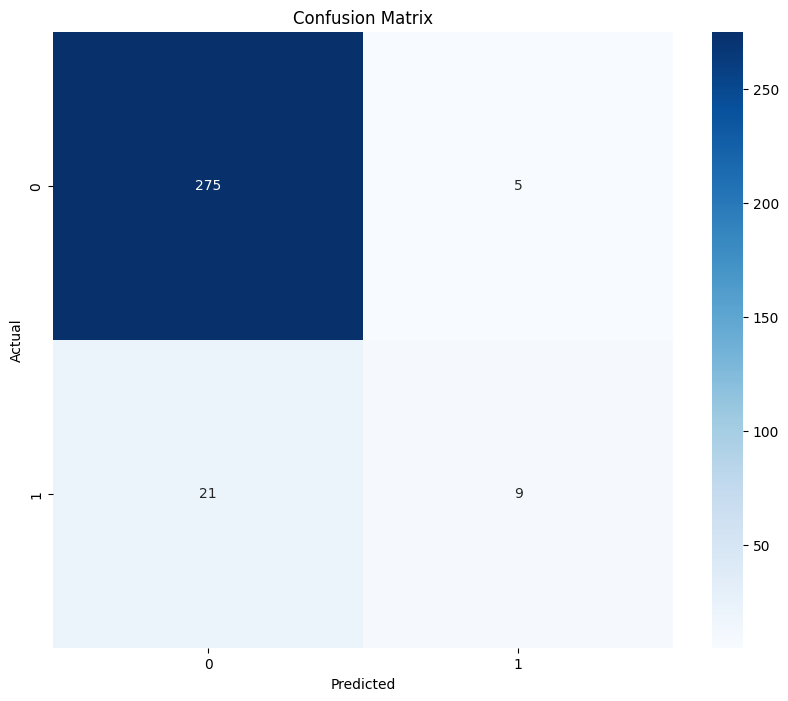

In [ ]:
# Define objective function for Optuna
def objective(trial):
    # Suggest hyperparameters for CatBoostClassifier
    iterations = trial.suggest_int('iterations', 50, 300)
    depth = trial.suggest_int('depth', 3, 15)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3)
    l2_leaf_reg = trial.suggest_float('l2_leaf_reg', 1e-3, 10.0)
    bagging_temperature = trial.suggest_float('bagging_temperature', 0.0, 1.0)

    # Create the model
    model = CatBoostClassifier(
        iterations=iterations,
        depth=depth,
        learning_rate=learning_rate,
        l2_leaf_reg=l2_leaf_reg,
        bagging_temperature=bagging_temperature,
        random_seed=0,
        verbose=0  # Set verbose to 0 for less output
    )

    # Fit the model
    model.fit(X_train_resampled, y_train_resampled)

    # Get predicted probabilities for the positive class
    y_probs = model.predict_proba(X_test_processed)[:, 1]

    # Calculate the ROC curve points
    fpr, tpr, thresholds = roc_curve(y_test, y_probs, pos_label=1)

    # Calculate specificity (1 - FPR)
    specificity = 1 - fpr

    # Calculate geometric mean for each threshold
    gmeans = [geometric_mean(tpr[i], specificity[i]) for i in range(len(tpr))]

    # Find the threshold that gives the best geometric mean
    optimal_idx = np.argmax(gmeans)
    optimal_threshold = thresholds[optimal_idx]

    # Make predictions using the optimal threshold
    y_pred = (y_probs >= optimal_threshold).astype(int)

    # Calculate the F1-weighted and recall metrics
    f1_weighted_avg = f1_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, pos_label=1)

    # Penalize models that don't meet the criteria
    if f1_weighted_avg < 0.8 or recall < 0.8:
        return 0  # Set to zero or negative to discard this trial

    # Return a combination of recall and F1-weighted average
    # The objective is to maximize recall while keeping it higher than F1-weighted average
    return (f1_weighted_avg + recall) / 2

# Create study and optimize
study = optuna.create_study(direction='maximize')  # Maximize the objective function
study.optimize(objective, n_trials=20)

# Get best hyperparameters
best_params = study.best_params
print("Best hyperparameters:", best_params)

# Train the model with best hyperparameters
best_model_tuning = CatBoostClassifier(
    iterations=best_params['iterations'],
    depth=best_params['depth'],
    learning_rate=best_params['learning_rate'],
    l2_leaf_reg=best_params['l2_leaf_reg'],
    bagging_temperature=best_params['bagging_temperature'],
    random_seed=0,
    verbose=0
)

best_model_tuning.fit(X_train_resampled, y_train_resampled)

# Predict and evaluate the best model
y_pred_best = best_model_tuning.predict(X_test_processed)
f1_weighted_avg_best = f1_score(y_test, y_pred_best, average='weighted')
recall_best = recall_score(y_test, y_pred_best, pos_label=1)

print("Best model F1-weighted avg:", f1_weighted_avg_best)
print("Best model recall:", recall_best)

# Print classification report
print(f"Classification Report")
print(classification_report(y_test, y_pred_best, digits=3))

# Plot the confusion matrix heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix')
plt.show()


In [ ]:
'iterations': 241, 'depth': 7, 'learning_rate': 0.08404570016647138, 'l2_leaf_reg': 5.903548361365323, 'bagging_temperature': 0.46242928274984324

In [ ]:
best_params = {
    'iterations': 241,
    'depth': 7,
    'learning_rate': 0.08404570016647138,
    'l2_leaf_reg': 5.903548361365323,
    'bagging_temperature': 0.46242928274984324
}

Best model F1-weighted avg: 0.9065249266862171
Best model recall: 0.36666666666666664
Classification Report
              precision    recall  f1-score   support

           0      0.935     0.975     0.955       280
           1      0.611     0.367     0.458        30

    accuracy                          0.916       310
   macro avg      0.773     0.671     0.706       310
weighted avg      0.904     0.916     0.907       310



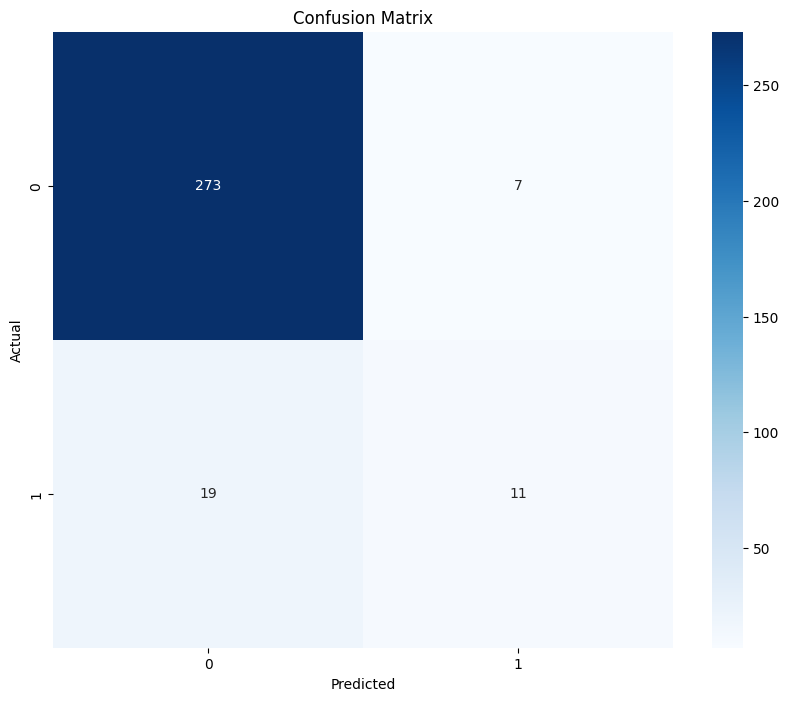

In [ ]:
# Train the model with best hyperparameters
best_model_tuning = CatBoostClassifier(
    iterations=best_params['iterations'],
    depth=best_params['depth'],
    learning_rate=best_params['learning_rate'],
    l2_leaf_reg=best_params['l2_leaf_reg'],
    bagging_temperature=best_params['bagging_temperature'],
    random_seed=0,
    verbose=0
)

best_model_tuning.fit(X_train_resampled, y_train_resampled)

# Predict and evaluate the best model
y_pred_best = best_model_tuning.predict(X_test_processed)
f1_weighted_avg_best = f1_score(y_test, y_pred_best, average='weighted')
recall_best = recall_score(y_test, y_pred_best, pos_label=1)

print("Best model F1-weighted avg:", f1_weighted_avg_best)
print("Best model recall:", recall_best)

# Print classification report
print(f"Classification Report")
print(classification_report(y_test, y_pred_best, digits=3))

# Plot the confusion matrix heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix')
plt.show()

## Post Analysis

In [ ]:
X_train_resampled

array([[-0.52455662,  0.06859464,  1.22363547, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.9635702 , -0.31620011, -0.48783208, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.71950679,  1.80017101,  0.22649669, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 2.30689567,  0.20789591, -0.26995279, ...,  0.        ,
         0.        ,  0.        ],
       [ 2.15576011,  0.23126938, -0.31347396, ...,  0.        ,
         0.        ,  0.        ],
       [ 3.2398252 , -0.12380274,  0.24771053, ...,  0.        ,
         0.        ,  0.        ]])

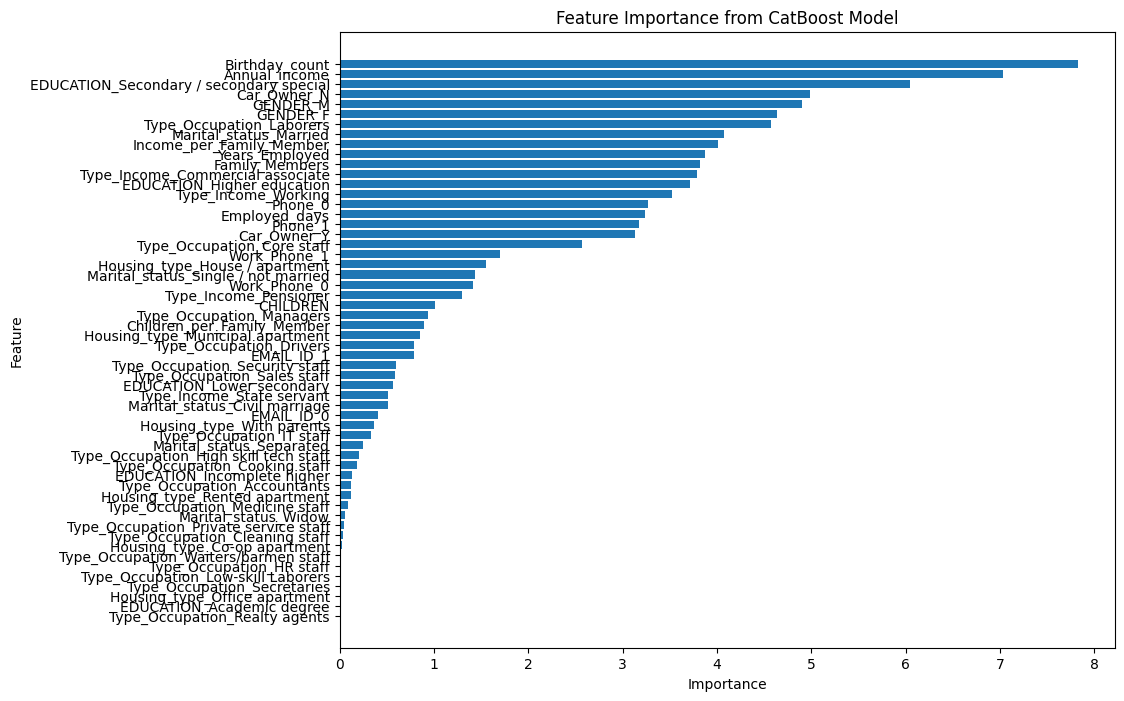

In [ ]:
# Feature importance
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
feature_importances = best_model_tuning.get_feature_importance()
features = X_train_resampled_df.columns  # Assumes X_train_resampled is a DataFrame with column names
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance from CatBoost Model")
plt.show()


In [ ]:
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 540.1/540.1 kB 9.6 MB/s eta 0:00:00


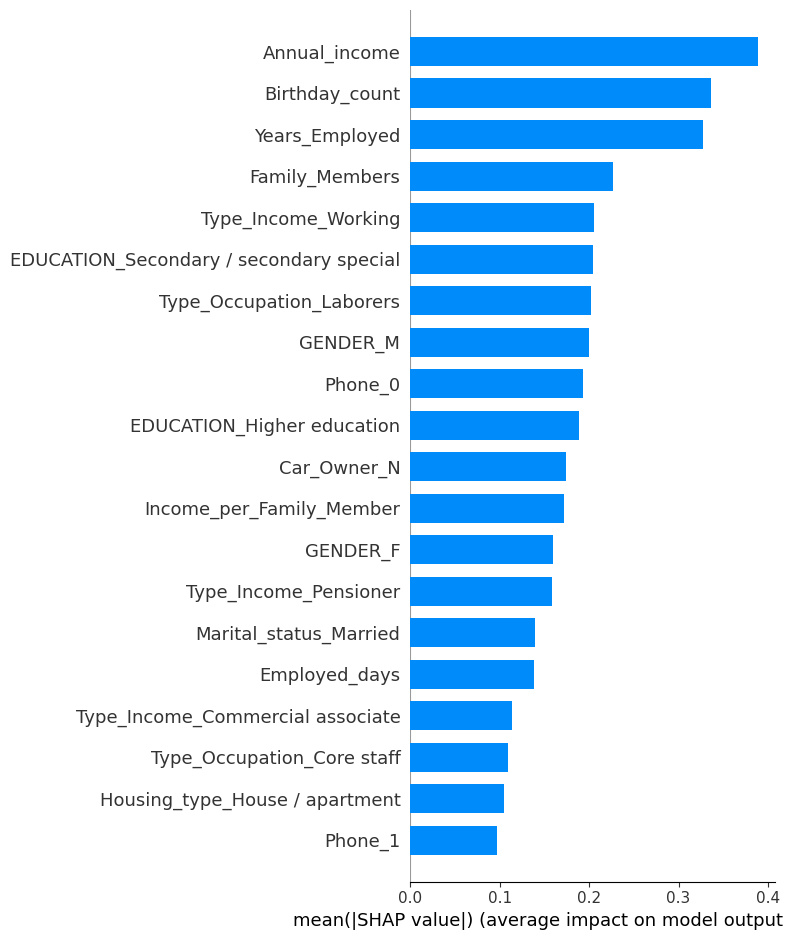

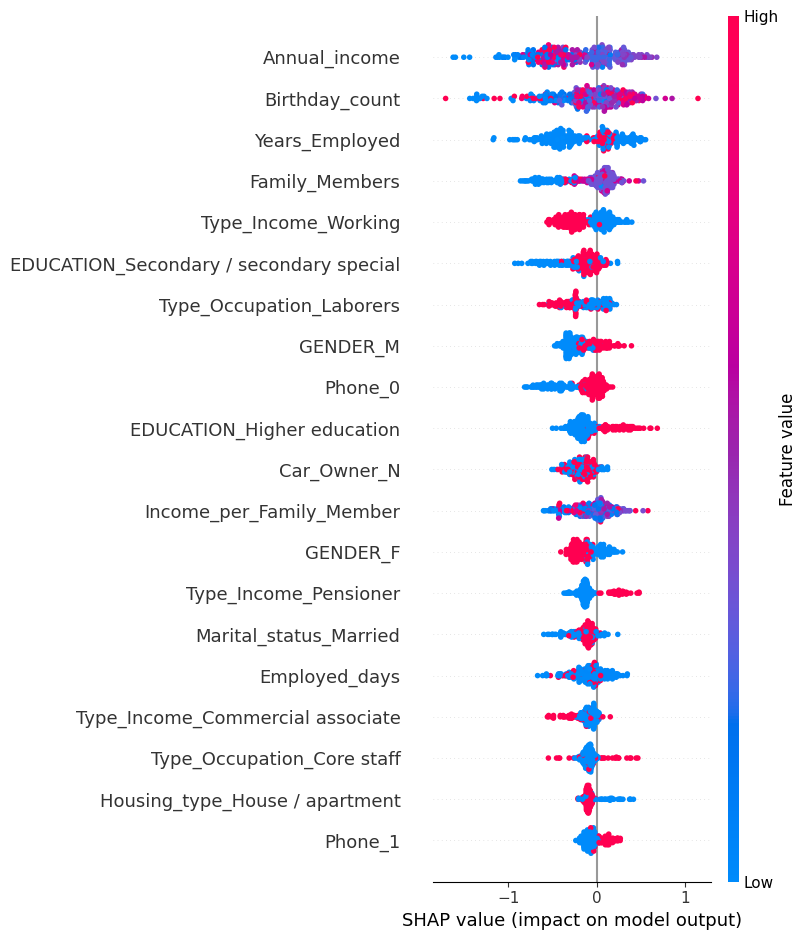

In [ ]:
import shap

# Initialize the SHAP explainer with the best model
explainer = shap.TreeExplainer(best_model_tuning)
shap_values = explainer.shap_values(X_test_processed_df)

# Summary plot of SHAP values (overall impact of features on model output)
shap.summary_plot(shap_values, X_test_processed_df, feature_names=X_test_processed_df.columns, plot_type="bar")

# Detailed summary plot with individual SHAP values
shap.summary_plot(shap_values, X_test_processed_df, feature_names=X_test_processed_df.columns)

# Optional: SHAP force plot for a single observation
# For example, visualize SHAP values for the first observation in the test set
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0], X_test_processed_df.iloc[0])
